Downloaded columns: [('Adj Close', 'GOOG'), ('Close', 'GOOG'), ('High', 'GOOG'), ('Low', 'GOOG'), ('Open', 'GOOG'), ('Volume', 'GOOG')]
Columns after flattening: ['closeGOOG', 'volumeGOOG']
Prepared data: T=2010, K=2
Compiling NLL (numba)...
Numba compiled.
Starting FA optimization (this may take some time)...
[FA] gen 1/200 best avg-NLL=1732.210283, alpha=0.59700
[FA] gen 25/200 best avg-NLL=879.552850, alpha=0.52933
[FA] gen 50/200 best avg-NLL=872.123985, alpha=0.46699
[FA] gen 75/200 best avg-NLL=872.123985, alpha=0.41199
[FA] gen 100/200 best avg-NLL=865.715320, alpha=0.36346
[FA] gen 125/200 best avg-NLL=857.153885, alpha=0.32065
[FA] gen 150/200 best avg-NLL=853.866523, alpha=0.28289
[FA] gen 175/200 best avg-NLL=853.862079, alpha=0.24957
[FA] gen 200/200 best avg-NLL=852.744887, alpha=0.22017
FA completed in 2.9s. Best avg-NLL = 852.744887

Estimated parameters (final):
omega = 1.051183e-03
alpha = 0.000065
beta  = 0.994933
alpha+beta = 0.994997
gamma_1 = -0.042120
gamma_2 = 2.

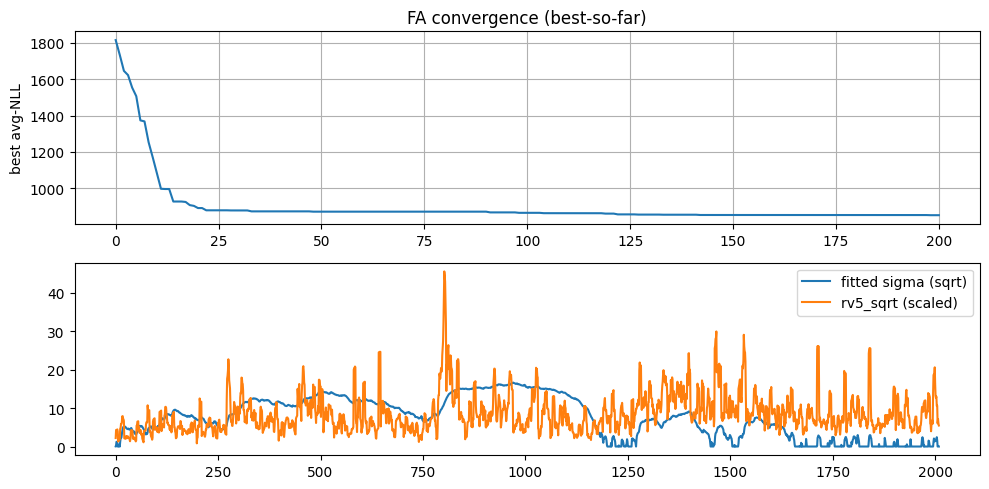


Done. Tweaks implemented: 
- If alpha+beta is very close to 1, consider enforcing beta = v2*(1-alpha) or lowering ALPHA_BETA_MAX.
- If standardized residuals have heavy tails, consider Student-t likelihood (modify NLL).
- If gammas are large, increase GAMMA_L2_LAMBDA or rescale exogenous regressors.
- For robust performance, run multiple FA restarts and compare parameter dispersion.


In [ ]:
#libraries
import time, math
import numpy as np
import pandas as pd
import yfinance as yf
#ticker data import
main_ticker = "GOOG"
start = "2017-01-01"
end = "2025-01-01"
main = yf.download(main_ticker, start=start, end=end, progress=False, auto_adjust=False)

# seeing our columns
print("Downloaded columns:", main.columns.tolist())

if 'Adj Close' in main.columns:
    close_col = 'Adj Close'
elif 'Close' in main.columns:
    close_col = 'Close'

# Keep close and volume
if 'Volume' not in main.columns and 'volume' not in main.columns:
    raise SystemExit("No Volume column found in downloaded data.")
vol_key = 'Volume' if 'Volume' in main.columns else 'volume'

main = main[[close_col, vol_key]].rename(columns={close_col: 'close', vol_key: 'volume'})

# Flatten the column names to a single level (no-op typically)
main.columns = [''.join(col).strip() if isinstance(col, tuple) else col for col in main.columns]

print("Columns after flattening:", main.columns.tolist())

# -----------------------
# 2) Feature engineering & alignment
# -----------------------
# Defensive renaming if needed
if 'close' not in main.columns:
    # try find a Close-like column
    found = None
    for c in main.columns:
        if 'close' in str(c).lower():
            found = c; break
    if found:
        main = main.rename(columns={found: 'close'})
if 'volume' not in main.columns:
    found = None
    for c in main.columns:
        if 'vol' in str(c).lower():
            found = c; break
    if found:
        main = main.rename(columns={found: 'volume'})



# Numerical conversions
main['close'] = pd.to_numeric(main['close'], errors='coerce')
main['volume'] = pd.to_numeric(main['volume'], errors='coerce')

# constants
eps = 1e-8

#log returns
main['log_ret'] = np.log(main['close']/main['close'].shift(1))
main = main.dropna(subset=['log_ret'])

# squared returns and 5-day realized variance proxy
#sq returns and 5 day realized variance--> proxy for volatility
main['sq_ret'] = main['log_ret'] ** 2
main['rv5'] = main['sq_ret'].rolling(window=5, min_periods=1).sum()
main['rv5_sqrt'] = np.sqrt(main['rv5'] + eps)
main['log_rv5'] = np.log(main['rv5'] + eps)

# lag exogenous regressors (use t-1)
main['vol_proxy_lag'] = main['rv5_sqrt'].shift(1)
main['log_rv5_lag'] = main['log_rv5'].shift(1)
main['log_volume'] = np.log(main['volume'].replace(0, np.nan) + 1.0)
main['log_volume_lag'] = main['log_volume'].shift(1)

# z-score lagged exogs (global mean/std here)
for c in ['vol_proxy_lag', 'log_rv5_lag', 'log_volume_lag']:
    m = main[c].mean(skipna=True)
    s = main[c].std(skipna=True) + eps
    main[c + '_z'] = (main[c] - m) / s

# drop rows where lagged exogs are NA (alignment)
main = main.dropna(subset=['vol_proxy_lag_z', 'log_volume_lag_z'])

# arrays for model
returns = main['log_ret'].values.astype(np.float64)
X = main[['vol_proxy_lag_z', 'log_volume_lag_z']].values.astype(np.float64)
T = len(returns)
K = X.shape[1]
print(f"Prepared data: T={T}, K={K}")

# demean returns (model residuals)
returns = returns - np.mean(returns)

# -----------------------
# 3) Numba compiled average NLL
# -----------------------
from numba import njit

@njit
def sigmoid_num(x):
    return 1.0 / (1.0 + math.exp(-x))

@njit
def garchx_avg_nll_numba(u, returns, X, eps_floor):
    Tloc = returns.shape[0]
    Kloc = X.shape[1]

    # mapping u to parameters
    omega = math.exp(u[0])
    v1=sigmoid_num(u[1])
    v2=sigmoid_num(u[2])
    eps_small=1e-8
    alpha=v1*(1.0 - eps_small)
    beta=v2*(1.0 - alpha - eps_small)
    # gamas with sign
    gammas=np.empty(Kloc, dtype=np.float64)
    for kk in range(Kloc):
        gammas[kk]=u[3 + kk]

    # simple plausibility checks
    if not np.isfinite(omega) or omega <= 0.0:
        return 1e12
    if not np.isfinite(alpha) or not np.isfinite(beta):
        return 1e12

    sigma2 = np.empty(Tloc, dtype=np.float64)
    # initializing using sample variance
    s_var=0.0
    for t in range(Tloc):
        s_var+=returns[t]*returns[t]
    s_var=s_var/Tloc if Tloc > 0 else 1e-8
    if s_var<=0.0:
        s_var=1e-8
    sigma2[0]=s_var if s_var > omega else omega

    # recursion with floor & sanity checks
    for t in range(1, Tloc):
        exog_term = 0.0
        for kk in range(Kloc):
            exog_term += gammas[kk] * X[t, kk]
        s2 = omega + alpha * (returns[t-1] ** 2.0) + beta * sigma2[t-1] + exog_term
        if not np.isfinite(s2):
            return 1e12
        if s2 <= 0.0:
            s2 = eps_floor
        if s2 > 1e8:
            return 1e12
        sigma2[t] = s2

    # average Gaussian NLL
    total=0.0
    for t in range(Tloc):
        total+=(0.5*(math.log(2.0*math.pi)+math.log(sigma2[t]+eps_floor)+(returns[t]**2.0)/(sigma2[t]+ eps_floor)))
    avg_nll = total/Tloc
    if not np.isfinite(avg_nll):
        return 1e12
    return avg_nll

# warm compile
_dummy = np.zeros(3 + K, dtype=np.float64)
print("Compiling NLL (numba)...")
_ = garchx_avg_nll_numba(_dummy, returns, X, eps)
print("Numba compiled.")

# Python wrapper
def nll_base(u):
    return float(garchx_avg_nll_numba(np.asarray(u, dtype=np.float64), returns, X, eps))

# -----------------------
# 4) Firefly Algorithm + safe wrapper (penalties)
# -----------------------
import numpy.random as npr

# safety & regularization settings
LARGE_PENALTY = 1e9
ALPHA_BETA_MAX = 0.995
GAMMA_L2_LAMBDA = 1e-3

def alpha_beta_from_u(u):
    u = np.asarray(u, dtype=np.float64)
    v1 = 1.0 / (1.0 + np.exp(-u[1]))
    v2 = 1.0 / (1.0 + np.exp(-u[2]))
    eps_small = 1e-8
    alpha = float(v1 * (1.0 - eps_small))
    beta = float(v2 * (1.0 - alpha - eps_small))
    return alpha, beta

def nll_with_penalties(u):
    # penalize near unit-root
    try:
        alpha, beta = alpha_beta_from_u(u)
    except Exception:
        return LARGE_PENALTY
    if not np.isfinite(alpha) or not np.isfinite(beta):
        return LARGE_PENALTY
    if alpha + beta > ALPHA_BETA_MAX:
        return LARGE_PENALTY
    base = nll_base(u)
    # small L2 penalty on gammas
    gam = np.asarray(u[3:], dtype=np.float64)
    reg = GAMMA_L2_LAMBDA * np.sum(gam * gam)
    return base + reg

# map u->theta for reporting
def u_to_theta(u, Kloc):
    u = np.asarray(u, dtype=np.float64)
    omega = float(np.exp(u[0]))
    v1 = 1.0 / (1.0 + np.exp(-u[1]))
    v2 = 1.0 / (1.0 + np.exp(-u[2]))
    eps_small = 1e-8
    alpha = float(v1 * (1.0 - eps_small))
    beta = float(v2 * (1.0 - alpha - eps_small))
    gammas = u[3:3+Kloc].copy()
    return omega, alpha, beta, gammas

# initialize population sensibly
def init_population(pop, dim, seed=2025):
    rng = npr.default_rng(seed)
    P = rng.normal(0.0, 1.0, size=(pop, dim))
    sample_var = max(np.var(returns), 1e-8)
    log_var = math.log(sample_var)
    P[:,0] = log_var + rng.normal(0.0, 0.3, size=pop)
    P[:,1] = np.log(0.06 / (1 - 0.06)) + rng.normal(0.0, 0.2, size=pop)
    P[:,2] = np.log(0.9 / (1 - 0.9)) + rng.normal(0.0, 0.2, size=pop)
    if dim > 3:
        P[:,3:] = rng.normal(0.0, 0.15, size=(pop, dim-3))
    return P

# Firefly algorithm (stochastic subset updates to reduce O(n^2))
def firefly_opt(func, dim, pop=40, gens=200, alpha0=0.6, alpha_decay=0.995,beta0=1.0,gamma_vis=0.5, subset_j=10, seed=2025):
    rng = npr.default_rng(seed)
    popM = init_population(pop, dim, seed=seed)
    obj = np.array([func(popM[i]) for i in range(pop)], dtype=np.float64)
    best_idx = int(np.argmin(obj))
    best_u = popM[best_idx].copy()
    best_obj = float(obj[best_idx])
    history = [best_obj]
    alpha = alpha0

    for gen in range(gens):
        order = rng.permutation(pop)
        for i in order:
            if pop <= 1:
                break
            m = min(subset_j, pop - 1)
            choices = rng.choice(pop - 1, size=m, replace=False)
            Js = []
            for c in choices:
                idx = c if c < i else c + 1
                Js.append(idx)
            for j in Js:
                if obj[j] < obj[i]:
                    rij = np.linalg.norm(popM[i] - popM[j])
                    beta = beta0 * math.exp(-gamma_vis * (rij ** 2))
                    attraction = beta * (popM[j] - popM[i])
                    rnd = alpha * (rng.random(dim) - 0.5)
                    popM[i] = popM[i] + attraction + rnd
                    val = func(popM[i])
                    obj[i] = val
                    if val < best_obj:
                        best_obj = float(val)
                        best_u = popM[i].copy()
        alpha = alpha * alpha_decay
        history.append(best_obj)
        if (gen + 1) % max(1, gens // 8) == 0 or gen == 0:
            print(f"[FA] gen {gen+1}/{gens} best avg-NLL={best_obj:.6f}, alpha={alpha:.5f}")
    return best_u, best_obj, history

# -----------------------
# 5) Run FA
# -----------------------
dim = 3 + K
print("Starting FA optimization (this may take some time)...")
t0 = time.time()
best_u, best_obj, history = firefly_opt(nll_with_penalties, dim,
                                       pop=40, gens=200, alpha0=0.6, alpha_decay=0.995,
                                       beta0=1.0, gamma_vis=0.5, subset_j=10, seed=2025)
t1 = time.time()
print(f"FA completed in {t1 - t0:.1f}s. Best avg-NLL = {best_obj:.6f}")



# map to parameters
omega_hat, alpha_hat, beta_hat, gammas_hat = u_to_theta(best_u, K)
print("\nEstimated parameters (final):")
print(f"omega = {omega_hat:.6e}")
print(f"alpha = {alpha_hat:.6f}")
print(f"beta  = {beta_hat:.6f}")
print(f"alpha+beta = {alpha_hat + beta_hat:.6f}")
for kk in range(K):
    print(f"gamma_{kk+1} = {gammas_hat[kk]:.6f}")

# -----------------------
# 6) Diagnostics & tests
# -----------------------
# compute fitted sigma^2
def compute_sigma2(u, returns, X, eps_floor=eps):
    omega, alpha, beta, gammas = u_to_theta(u, X.shape[1])
    Tloc = len(returns)
    sigma2 = np.empty(Tloc, dtype=np.float64)
    sample_var = np.var(returns)
    sigma2[0] = max(sample_var, omega, eps_floor)
    for t in range(1, Tloc):
        exog = float(np.dot(gammas, X[t])) if X.shape[1] > 0 else 0.0
        s2 = omega + alpha * (returns[t-1] ** 2.0) + beta * sigma2[t-1] + exog
        sigma2[t] = max(s2, eps_floor)
    return sigma2

sigma2_hat = compute_sigma2(best_u, returns, X, eps)
print("\nSigma^2 summary (min, mean, max):", sigma2_hat.min(), sigma2_hat.mean(), sigma2_hat.max())

# standardized residuals
z = returns / np.sqrt(sigma2_hat + eps)
print("\nStandardized residuals: mean, std:", z.mean(), z.std())

# skewness & kurtosis
try:
    from scipy import stats
    sk = stats.skew(z)
    kurt = stats.kurtosis(z, fisher=False)
    print("skewness, kurtosis:", sk, kurt)
except Exception:
    pass

#NOT NEEDD
# Ljung-Box tests if statsmodels present
try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb_res = acorr_ljungbox(z, lags=[10,20], return_df=True)
    lb_sq = acorr_ljungbox(z**2, lags=[10,20], return_df=True)
    print("\nLjung-Box (residuals) lb_stat / pvalue:\n", lb_res[['lb_stat','lb_pvalue']])
    print("\nLjung-Box (squared residuals) lb_stat / pvalue:\n", lb_sq[['lb_stat','lb_pvalue']])
except Exception:
    print("\nstatsmodels not available — skipping Ljung-Box tests.")

# Losses vs squared returns (in-sample)
obs_sq = main['sq_ret'].values[-len(sigma2_hat):].astype(np.float64)
mse = np.mean((obs_sq - sigma2_hat) ** 2)
qlike = np.mean(np.log(sigma2_hat + eps) + obs_sq / (sigma2_hat + eps))
print(f"\nIn-sample losses: MSE = {mse:.6e}, QLIKE = {qlike:.6f}")

# VaR backtest (normal) at 1% and 5%
from scipy.stats import norm
for a in [0.01, 0.05]:
    thresh = norm.ppf(a)
    var_thresh = np.sqrt(sigma2_hat) * thresh  # returns threshold
    exceptions = np.sum(returns < var_thresh)
    expected = a * len(returns)
    print(f"VaR {int(a*100)}%: exceptions = {exceptions}, expected ≈ {expected:.1f}, exception rate = {exceptions/len(returns):.4f}")

#--> main diagonistics.
# -----------------------
# 7) Plots (convergence + fitted vol vs proxy)
# -----------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(history, lw=1.5)
plt.title("FA convergence (best-so-far)")
plt.ylabel("best avg-NLL")
plt.grid(True)

plt.subplot(2,1,2)
fitted_s = np.sqrt(sigma2_hat)
proxy = main['rv5_sqrt'].values[-len(fitted_s):]
# scale proxy to median of fitted for visibility
scale = np.median(fitted_s) / (np.median(proxy) + eps)
plt.plot(fitted_s, label='fitted sigma (sqrt)')
plt.plot(proxy * scale, label='rv5_sqrt (scaled)')
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------
# 8) Final recommendations printed
# -----------------------
print("\nDone. Tweaks implemented: ")
print("- If alpha+beta is very close to 1, consider enforcing beta = v2*(1-alpha) or lowering ALPHA_BETA_MAX.")
print("- If standardized residuals have heavy tails, consider Student-t likelihood (modify NLL).")
print("- If gammas are large, increase GAMMA_L2_LAMBDA or rescale exogenous regressors.")
print("- For robust performance, run multiple FA restarts and compare parameter dispersion.")


Downloaded columns: [('Adj Close', 'GOOG'), ('Close', 'GOOG'), ('High', 'GOOG'), ('Low', 'GOOG'), ('Open', 'GOOG'), ('Volume', 'GOOG')]
Prepared data: T=2010, K=2
Compiling NLL (numba)...
Numba compiled.
Starting Firefly optimization...
[FA] gen 20/100 best avg-NLL=1.975288
[FA] gen 40/100 best avg-NLL=1.974918
[FA] gen 60/100 best avg-NLL=1.974072
[FA] gen 80/100 best avg-NLL=1.974072
[FA] gen 100/100 best avg-NLL=1.973597
FA completed in 5.7s. FA NLL = 1.973597

Polishing result with Gradient Descent (L-BFGS-B)...
Polished NLL: 1.973597 (Improvement: 0.000000e+00)

Estimated parameters (final):
omega = 0.802102
alpha = 0.087831
beta  = 0.643644
Persistence (a+b) = 0.731475
gamma_1 = 0.040533
gamma_2 = 0.038652

Sigma^2 summary (min, mean, max): 1.7043062447694861 3.4751568482442448 50.01839584559071

Standardized residuals: mean, std: 0.0032341874704185365 1.002144151531339
Skewness: -0.2697, Kurtosis: 7.5937 (Normal=3.0)

Ljung-Box (z^2) p-value (should be > 0.05):
0.995068718150027

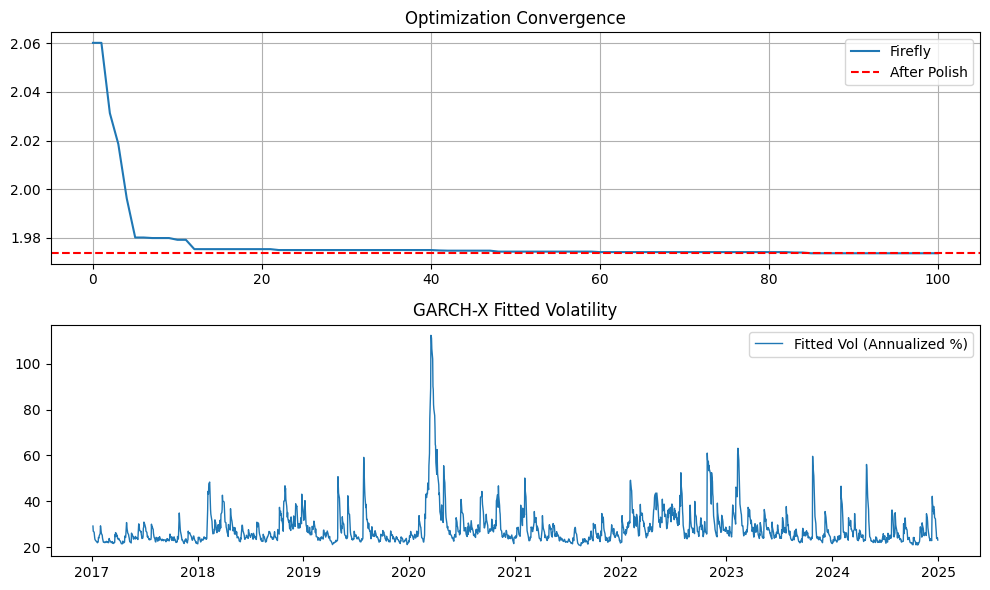


Final Script Completed.


In [ ]:
#libraries
import time, math
import numpy as np
import pandas as pd
import yfinance as yf
import numpy.random as npr
from scipy.optimize import minimize
from numba import njit
import matplotlib.pyplot as plt

# -----------------------
# 1) Data Download & Prep
# -----------------------
#ticker data import
main_ticker = "GOOG"
start = "2017-01-01"
end = "2025-01-01"
main = yf.download(main_ticker, start=start, end=end, progress=False, auto_adjust=False)

# seeing our columns
print("Downloaded columns:", main.columns.tolist())

if 'Adj Close' in main.columns:
    close_col = 'Adj Close'
elif 'Close' in main.columns:
    close_col = 'Close'
else:
    close_col = main.columns[0] # Fallback

# Keep close and volume
# Handle MultiIndex if necessary
if isinstance(main.columns, pd.MultiIndex):
    main.columns = [''.join(col).strip() for col in main.columns.values]

# Defensive column finding
close_col_final = None
vol_col_final = None

for c in main.columns:
    if 'close' in c.lower():
        close_col_final = c
    if 'volume' in c.lower():
        vol_col_final = c

if not close_col_final or not vol_col_final:
    raise SystemExit(f"Could not identify Close/Volume columns. Found: {main.columns.tolist()}")

main = main[[close_col_final, vol_col_final]].rename(columns={close_col_final: 'close', vol_col_final: 'volume'})

# Numerical conversions
main['close'] = pd.to_numeric(main['close'], errors='coerce')
main['volume'] = pd.to_numeric(main['volume'], errors='coerce')

# constants
eps = 1e-8

# -----------------------
# [IMPROVEMENT 1] Rescale Returns
# -----------------------
# We multiply by 100 so returns are in percentages (e.g., 1.5 instead of 0.015).
# This prevents precision errors and "vanishing" gradients.
main['log_ret'] = np.log(main['close']/main['close'].shift(1)) * 100.0
main = main.dropna(subset=['log_ret'])

# squared returns and 5-day realized variance proxy
main['sq_ret'] = main['log_ret'] ** 2
main['rv5'] = main['sq_ret'].rolling(window=5, min_periods=1).sum()
main['rv5_sqrt'] = np.sqrt(main['rv5'] + eps)
main['log_rv5'] = np.log(main['rv5'] + eps)

# lag exogenous regressors (use t-1)
main['vol_proxy_lag'] = main['rv5_sqrt'].shift(1)
main['log_rv5_lag'] = main['log_rv5'].shift(1)
main['log_volume'] = np.log(main['volume'].replace(0, np.nan) + 1.0)
main['log_volume_lag'] = main['log_volume'].shift(1)

# z-score lagged exogs (global mean/std here)
for c in ['vol_proxy_lag', 'log_rv5_lag', 'log_volume_lag']:
    m = main[c].mean(skipna=True)
    s = main[c].std(skipna=True) + eps
    main[c + '_z'] = (main[c] - m) / s

# drop rows where lagged exogs are NA (alignment)
main = main.dropna(subset=['vol_proxy_lag_z', 'log_volume_lag_z'])

# arrays for model
returns = main['log_ret'].values.astype(np.float64)
# Using Z-scored Volume and Realized Volatility as exogenous inputs
X = main[['vol_proxy_lag_z', 'log_volume_lag_z']].values.astype(np.float64)
T = len(returns)
K = X.shape[1]
print(f"Prepared data: T={T}, K={K}")

# demean returns (model residuals)
returns = returns - np.mean(returns)

# -----------------------
# 3) Numba compiled average NLL (IMPROVED)
# -----------------------

@njit
def sigmoid_num(x):
    return 1.0 / (1.0 + math.exp(-x))

@njit
def garchx_avg_nll_numba(u, returns, X, eps_floor):
    Tloc = returns.shape[0]
    Kloc = X.shape[1]

    # mapping u to parameters
    omega = math.exp(u[0])
    v1 = sigmoid_num(u[1])
    v2 = sigmoid_num(u[2])
    eps_small = 1e-8
    alpha = v1 * (1.0 - eps_small)
    beta = v2 * (1.0 - alpha - eps_small)

    gammas = np.empty(Kloc, dtype=np.float64)
    for kk in range(Kloc):
        gammas[kk] = u[3 + kk]

    # simple plausibility checks
    if not np.isfinite(omega) or omega <= 0.0: return 1e12
    if not np.isfinite(alpha) or not np.isfinite(beta): return 1e12

    sigma2 = np.empty(Tloc, dtype=np.float64)

    # Initialize with sample variance
    s_var = 0.0
    for t in range(Tloc):
        s_var += returns[t]**2
    s_var = s_var/Tloc if Tloc > 0 else 1.0
    sigma2[0] = s_var

    # -----------------------
    # [IMPROVEMENT 2] Multiplicative Variance
    # -----------------------
    # Instead of s2 = GARCH + (gamma*X), we use s2 = GARCH * exp(gamma*X)
    # This ensures variance is ALWAYS positive, preventing the "crash" to eps_floor.

    avg_nll = 0.0

    for t in range(1, Tloc):
        # 1. Calculate the exogenous multiplier
        exog_log_mult = 0.0
        for kk in range(Kloc):
            exog_log_mult += gammas[kk] * X[t, kk]

        # Clip to prevent overflow (exp(20) is too big)
        if exog_log_mult > 10.0: exog_log_mult = 10.0
        if exog_log_mult < -10.0: exog_log_mult = -10.0

        exog_mult = math.exp(exog_log_mult)

        # 2. Standard GARCH component
        garch_core = omega + alpha * (returns[t-1] ** 2.0) + beta * sigma2[t-1]

        # 3. Combine
        s2 = garch_core * exog_mult

        if not np.isfinite(s2) or s2 > 1e8:
            return 1e12

        sigma2[t] = max(s2, eps_floor)

        # Accumulate Gaussian NLL
        avg_nll += 0.5 * (math.log(2.0 * math.pi) + math.log(sigma2[t]) + (returns[t]**2.0)/sigma2[t])

    return avg_nll / Tloc

# warm compile
_dummy = np.zeros(3 + K, dtype=np.float64)
print("Compiling NLL (numba)...")
_ = garchx_avg_nll_numba(_dummy, returns, X, eps)
print("Numba compiled.")

# Python wrapper
def nll_base(u):
    return float(garchx_avg_nll_numba(np.asarray(u, dtype=np.float64), returns, X, eps))

# -----------------------
# 4) Firefly Algorithm & Wrappers
# -----------------------
# safety & regularization settings
LARGE_PENALTY = 1e9
ALPHA_BETA_MAX = 0.999 # Relaxed slightly for Polishing
GAMMA_L2_LAMBDA = 1e-3

def alpha_beta_from_u(u):
    u = np.asarray(u, dtype=np.float64)
    v1 = 1.0 / (1.0 + np.exp(-u[1]))
    v2 = 1.0 / (1.0 + np.exp(-u[2]))
    eps_small = 1e-8
    alpha = float(v1 * (1.0 - eps_small))
    beta = float(v2 * (1.0 - alpha - eps_small))
    return alpha, beta

def nll_with_penalties(u):
    try:
        alpha, beta = alpha_beta_from_u(u)
    except Exception:
        return LARGE_PENALTY

    if not np.isfinite(alpha) or not np.isfinite(beta):
        return LARGE_PENALTY
    if alpha + beta > ALPHA_BETA_MAX:
        return LARGE_PENALTY

    base = nll_base(u)

    # L2 penalty on gammas
    gam = np.asarray(u[3:], dtype=np.float64)
    reg = GAMMA_L2_LAMBDA * np.sum(gam * gam)
    return base + reg

def u_to_theta(u, Kloc):
    u = np.asarray(u, dtype=np.float64)
    omega = float(np.exp(u[0]))
    alpha, beta = alpha_beta_from_u(u)
    gammas = u[3:3+Kloc].copy()
    return omega, alpha, beta, gammas

def init_population(pop, dim, seed=2025):
    rng = npr.default_rng(seed)
    P = rng.normal(0.0, 1.0, size=(pop, dim))

    # Smart initialization based on rescaled returns
    sample_var = max(np.var(returns), 1e-4)
    log_var = math.log(sample_var)

    P[:,0] = log_var + rng.normal(0.0, 0.5, size=pop) # omega
    P[:,1] = -2.0 + rng.normal(0.0, 0.5, size=pop)    # alpha (logit) ~ 0.10
    P[:,2] = 2.0 + rng.normal(0.0, 0.5, size=pop)     # beta (logit)  ~ 0.85

    if dim > 3:
        P[:,3:] = rng.normal(0.0, 0.1, size=(pop, dim-3)) # Small initial gammas
    return P

def firefly_opt(func, dim, pop=40, gens=100, alpha0=0.6, alpha_decay=0.99, beta0=1.0, gamma_vis=1.0, subset_j=10, seed=2025):
    rng = npr.default_rng(seed)
    popM = init_population(pop, dim, seed=seed)
    obj = np.array([func(popM[i]) for i in range(pop)], dtype=np.float64)

    best_idx = int(np.argmin(obj))
    best_u = popM[best_idx].copy()
    best_obj = float(obj[best_idx])
    history = [best_obj]
    alpha = alpha0

    for gen in range(gens):
        order = rng.permutation(pop)
        for i in order:
            m = min(subset_j, pop - 1)
            choices = rng.choice(pop - 1, size=m, replace=False)
            Js = [c if c < i else c + 1 for c in choices]

            for j in Js:
                if obj[j] < obj[i]:
                    rij = np.linalg.norm(popM[i] - popM[j])
                    beta = beta0 * math.exp(-gamma_vis * (rij ** 2))
                    attraction = beta * (popM[j] - popM[i])
                    rnd = alpha * (rng.random(dim) - 0.5)

                    candidate = popM[i] + attraction + rnd
                    val = func(candidate)

                    if val < obj[i]: # Move only if improved (optional variant)
                        popM[i] = candidate
                        obj[i] = val
                        if val < best_obj:
                            best_obj = float(val)
                            best_u = candidate.copy()

        alpha = alpha * alpha_decay
        history.append(best_obj)
        if (gen + 1) % 20 == 0:
            print(f"[FA] gen {gen+1}/{gens} best avg-NLL={best_obj:.6f}")

    return best_u, best_obj, history

# -----------------------
# 5) Optimization Routine
# -----------------------
dim = 3 + K
print("Starting Firefly optimization...")
t0 = time.time()
# Reduced gens slightly as we will polish afterwards
best_u_fa, best_obj_fa, history = firefly_opt(nll_with_penalties, dim, pop=40, gens=100)
t1 = time.time()
print(f"FA completed in {t1 - t0:.1f}s. FA NLL = {best_obj_fa:.6f}")

# -----------------------
# [IMPROVEMENT 3] Polishing with L-BFGS-B
# -----------------------
print("\nPolishing result with Gradient Descent (L-BFGS-B)...")
res_polish = minimize(nll_with_penalties, best_u_fa, method='L-BFGS-B', tol=1e-5)
best_u = res_polish.x
print(f"Polished NLL: {res_polish.fun:.6f} (Improvement: {best_obj_fa - res_polish.fun:.6e})")

# map to parameters
omega_hat, alpha_hat, beta_hat, gammas_hat = u_to_theta(best_u, K)
print("\nEstimated parameters (final):")
print(f"omega = {omega_hat:.6f}")
print(f"alpha = {alpha_hat:.6f}")
print(f"beta  = {beta_hat:.6f}")
print(f"Persistence (a+b) = {alpha_hat + beta_hat:.6f}")
for kk in range(K):
    print(f"gamma_{kk+1} = {gammas_hat[kk]:.6f}")

# -----------------------
# 6) Diagnostics & Tests (Aligned with New Model)
# -----------------------
def compute_sigma2(u, returns, X, eps_floor=eps):
    omega, alpha, beta, gammas = u_to_theta(u, X.shape[1])
    Tloc = len(returns)
    sigma2 = np.empty(Tloc, dtype=np.float64)
    sigma2[0] = np.var(returns)

    for t in range(1, Tloc):
        # Must match Numba logic exactly: Multiplicative
        exog_log = np.dot(gammas, X[t])
        exog_log = np.clip(exog_log, -10.0, 10.0)
        exog_mult = np.exp(exog_log)

        garch_core = omega + alpha * (returns[t-1] ** 2.0) + beta * sigma2[t-1]
        s2 = garch_core * exog_mult
        sigma2[t] = max(s2, eps_floor)
    return sigma2

sigma2_hat = compute_sigma2(best_u, returns, X, eps)
print("\nSigma^2 summary (min, mean, max):", sigma2_hat.min(), sigma2_hat.mean(), sigma2_hat.max())

# standardized residuals
z = returns / np.sqrt(sigma2_hat + eps)
print("\nStandardized residuals: mean, std:", z.mean(), z.std())
# Ideally std should be close to 1.0

try:
    from scipy import stats
    sk = stats.skew(z)
    kurt = stats.kurtosis(z, fisher=False) # Fisher=False means normal is 3.0
    print(f"Skewness: {sk:.4f}, Kurtosis: {kurt:.4f} (Normal=3.0)")
except Exception:
    pass

# Ljung-Box tests
try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb_sq = acorr_ljungbox(z**2, lags=[10], return_df=True)
    print("\nLjung-Box (z^2) p-value (should be > 0.05):")
    print(lb_sq['lb_pvalue'].values[0])
except Exception:
    pass

# Losses vs squared returns
obs_sq = main['sq_ret'].values[-len(sigma2_hat):]
mse = np.mean((obs_sq - sigma2_hat) ** 2)
qlike = np.mean(np.log(sigma2_hat + eps) + obs_sq / (sigma2_hat + eps))
print(f"\nIn-sample losses: MSE = {mse:.6f}, QLIKE = {qlike:.6f}")

# VaR backtest (normal)
from scipy.stats import norm
print("\nVaR Backtest:")
for a in [0.01, 0.05]:
    thresh = norm.ppf(a)
    # sigma_hat is already scaled to returns (because returns were scaled)
    var_thresh = np.sqrt(sigma2_hat) * thresh
    exceptions = np.sum(returns < var_thresh)
    rate = exceptions/len(returns)
    print(f"VaR {int(a*100)}%: {exceptions} exceptions ({rate*100:.2f}%) vs expected {a*100:.1f}%")

# -----------------------
# 7) Plots
# -----------------------
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(history, label='Firefly')
plt.axhline(y=res_polish.fun, color='r', linestyle='--', label='After Polish')
plt.title("Optimization Convergence")
plt.legend()
plt.grid(True)

plt.subplot(2,1,2)
# Plot fitted volatility (annualized approx)
# annualized vol % = sqrt(sigma2) * sqrt(252)
ann_vol = np.sqrt(sigma2_hat) * np.sqrt(252)
plt.plot(main.index[-len(ann_vol):], ann_vol, lw=1, label='Fitted Vol (Annualized %)')
plt.title("GARCH-X Fitted Volatility")
plt.legend()
plt.tight_layout()
plt.show()

print("\nFinal Script Completed.")



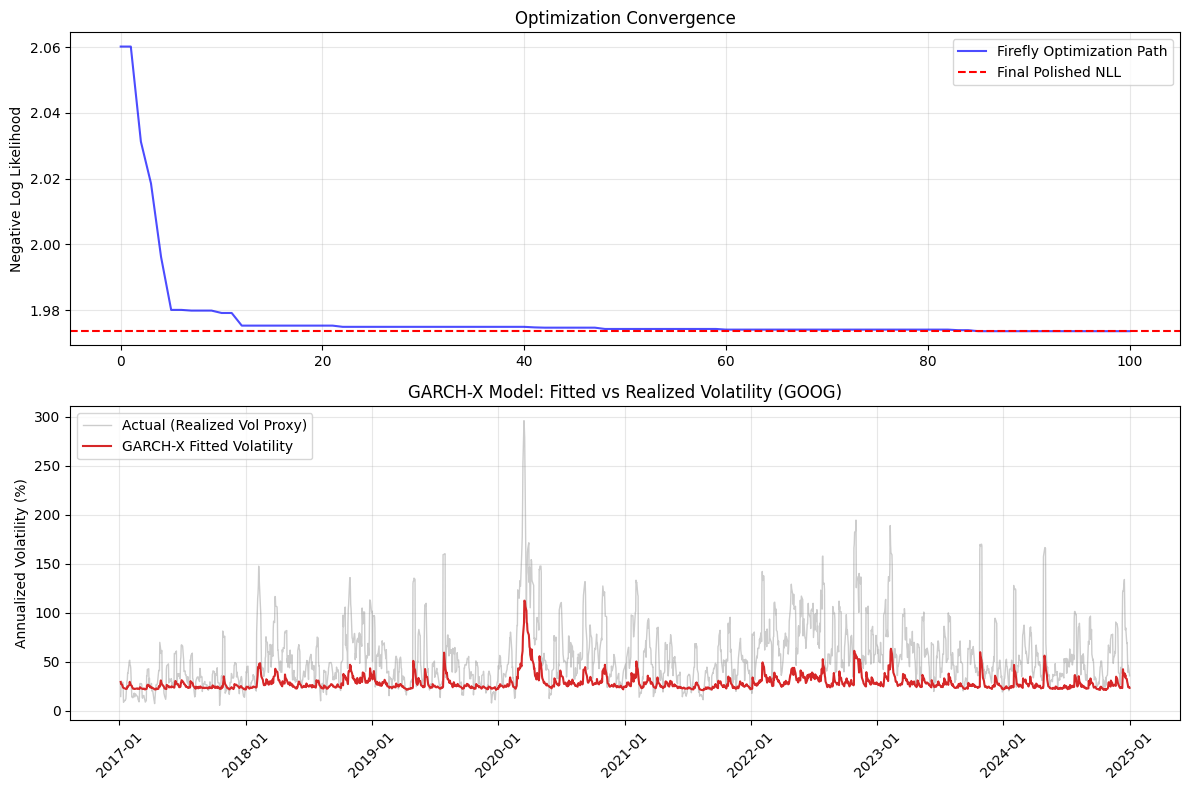

In [ ]:
# -----------------------
# 7) Plots: Actual vs Fitted
# -----------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Prepare data for plotting
# We use the 5-day Realized Volatility (rv5_sqrt) as the "Actual" proxy
# We align the last T elements (since we dropped NaNs at the start)
dates = main.index[-len(sigma2_hat):]
actual_vol = main['rv5_sqrt'].values[-len(sigma2_hat):]
fitted_vol = np.sqrt(sigma2_hat)

# Annualize them for easier reading (Standard Industry Practice)
# Annualized % = Daily % * sqrt(252)
scale_factor = np.sqrt(252)
actual_vol_ann = actual_vol * scale_factor
fitted_vol_ann = fitted_vol * scale_factor

plt.figure(figsize=(12, 8))

# Subplot 1: Optimization History
plt.subplot(2, 1, 1)
plt.plot(history, label='Firefly Optimization Path', color='blue', alpha=0.7)
plt.axhline(y=res_polish.fun, color='red', linestyle='--', linewidth=1.5, label='Final Polished NLL')
plt.title("Optimization Convergence")
plt.ylabel("Negative Log Likelihood")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Actual vs Fitted Volatility
plt.subplot(2, 1, 2)
plt.plot(dates, actual_vol_ann, color='grey', alpha=0.4, label='Actual (Realized Vol Proxy)', linewidth=1)
plt.plot(dates, fitted_vol_ann, color='#d62728', label='GARCH-X Fitted Volatility', linewidth=1.5)

plt.title(f"GARCH-X Model: Fitted vs Realized Volatility ({main_ticker})")
plt.ylabel("Annualized Volatility (%)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)# -----------------------
# 7) Plots: Actual vs Fitted
# -----------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Prepare data for plotting
# We use the 5-day Realized Volatility (rv5_sqrt) as the "Actual" proxy
# We align the last T elements (since we dropped NaNs at the start)
dates = main.index[-len(sigma2_hat):]
actual_vol = main['rv5_sqrt'].values[-len(sigma2_hat):]
fitted_vol = np.sqrt(sigma2_hat)

# Annualize them for easier reading (Standard Industry Practice)
# Annualized % = Daily % * sqrt(252)
scale_factor = np.sqrt(252)
actual_vol_ann = actual_vol * scale_factor
fitted_vol_ann = fitted_vol * scale_factor

plt.figure(figsize=(12, 8))

# Subplot 1: Optimization History
plt.subplot(2, 1, 1)
plt.plot(history, label='Firefly Optimization Path', color='blue', alpha=0.7)
plt.axhline(y=res_polish.fun, color='red', linestyle='--', linewidth=1.5, label='Final Polished NLL')
plt.title("Optimization Convergence")
plt.ylabel("Negative Log Likelihood")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Actual vs Fitted Volatility
plt.subplot(2, 1, 2)
plt.plot(dates, actual_vol_ann, color='grey', alpha=0.4, label='Actual (Realized Vol Proxy)', linewidth=1)
plt.plot(dates, fitted_vol_ann, color='#d62728', label='GARCH-X Fitted Volatility', linewidth=1.5)

plt.title(f"GARCH-X Model: Fitted vs Realized Volatility ({main_ticker})")
plt.ylabel("Annualized Volatility (%)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Format Date Axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Format Date Axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Downloaded columns: [('Adj Close', 'GOOG'), ('Close', 'GOOG'), ('High', 'GOOG'), ('Low', 'GOOG'), ('Open', 'GOOG'), ('Volume', 'GOOG')]
Prepared data: T=2010, K=2
Compiling NLL (numba)...
Numba compiled.
Starting Firefly optimization (NO Polishing)...
[FA] gen 1/200 best avg-NLL=2.060198
[FA] gen 20/200 best avg-NLL=1.975288
[FA] gen 40/200 best avg-NLL=1.974918
[FA] gen 60/200 best avg-NLL=1.974072
[FA] gen 80/200 best avg-NLL=1.974072
[FA] gen 100/200 best avg-NLL=1.973597
[FA] gen 120/200 best avg-NLL=1.973593
[FA] gen 140/200 best avg-NLL=1.973531
[FA] gen 160/200 best avg-NLL=1.973505
[FA] gen 180/200 best avg-NLL=1.973465
[FA] gen 200/200 best avg-NLL=1.973361
FA completed in 13.0s. Final NLL = 1.973361

Estimated parameters (final):
omega = 0.881263
alpha = 0.075571
beta  = 0.626681
Persistence (a+b) = 0.702252
gamma_1 = 0.047260
gamma_2 = 0.048086

Sigma^2 summary (min, mean, max): 1.7063724887935137 3.4865160443696737 53.66383404826941

Standardized residuals: mean, std: 0.002

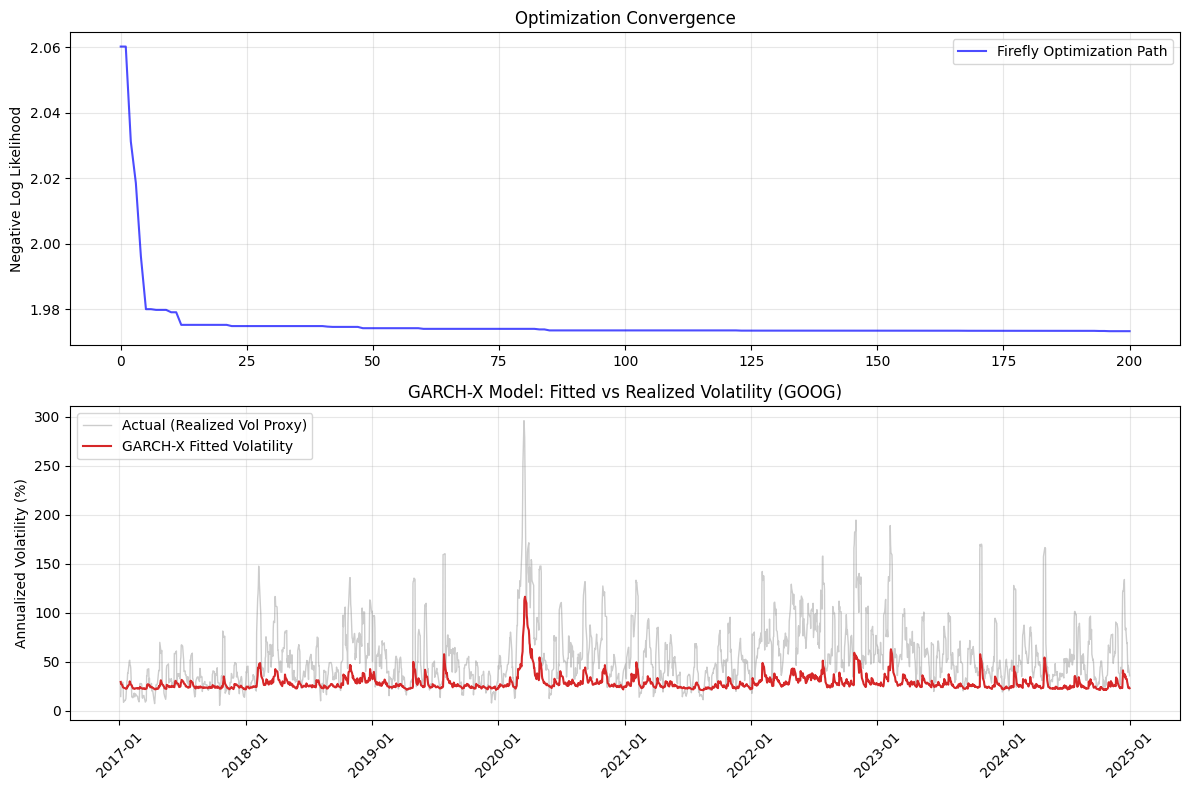


Final Script Completed.


In [ ]:
#libraries
import time, math
import numpy as np
import pandas as pd
import yfinance as yf
import numpy.random as npr
from numba import njit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------
# 1) Data Download & Prep
# -----------------------
#ticker data import
main_ticker = "GOOG"
start = "2017-01-01"
end = "2025-01-01"
main = yf.download(main_ticker, start=start, end=end, progress=False, auto_adjust=False)

# seeing our columns
print("Downloaded columns:", main.columns.tolist())

# Handle MultiIndex if necessary
if isinstance(main.columns, pd.MultiIndex):
    main.columns = [''.join(col).strip() for col in main.columns.values]

# Defensive column finding
close_col_final = None
vol_col_final = None

for c in main.columns:
    if 'close' in c.lower():
        close_col_final = c
    if 'volume' in c.lower():
        vol_col_final = c

if not close_col_final or not vol_col_final:
    # Fallback to defaults if fuzzy match fails
    if 'Close' in main.columns: close_col_final = 'Close'
    if 'Adj Close' in main.columns: close_col_final = 'Adj Close'
    if 'Volume' in main.columns: vol_col_final = 'Volume'

if not close_col_final or not vol_col_final:
    raise SystemExit(f"Could not identify Close/Volume columns. Found: {main.columns.tolist()}")

main = main[[close_col_final, vol_col_final]].rename(columns={close_col_final: 'close', vol_col_final: 'volume'})

# Numerical conversions
main['close'] = pd.to_numeric(main['close'], errors='coerce')
main['volume'] = pd.to_numeric(main['volume'], errors='coerce')

# constants
eps = 1e-8

# -----------------------
# [IMPROVEMENT 1] Rescale Returns
# -----------------------
# We multiply by 100 so returns are in percentages (e.g., 1.5 instead of 0.015).
main['log_ret'] = np.log(main['close']/main['close'].shift(1)) * 100.0
main = main.dropna(subset=['log_ret'])

# squared returns and 5-day realized variance proxy
main['sq_ret'] = main['log_ret'] ** 2
main['rv5'] = main['sq_ret'].rolling(window=5, min_periods=1).sum()
main['rv5_sqrt'] = np.sqrt(main['rv5'] + eps)
main['log_rv5'] = np.log(main['rv5'] + eps)

# lag exogenous regressors (use t-1)
main['vol_proxy_lag'] = main['rv5_sqrt'].shift(1)
main['log_rv5_lag'] = main['log_rv5'].shift(1)
main['log_volume'] = np.log(main['volume'].replace(0, np.nan) + 1.0)
main['log_volume_lag'] = main['log_volume'].shift(1)

# z-score lagged exogs (global mean/std here)
for c in ['vol_proxy_lag', 'log_rv5_lag', 'log_volume_lag']:
    m = main[c].mean(skipna=True)
    s = main[c].std(skipna=True) + eps
    main[c + '_z'] = (main[c] - m) / s

# drop rows where lagged exogs are NA (alignment)
main = main.dropna(subset=['vol_proxy_lag_z', 'log_volume_lag_z'])

# arrays for model
returns = main['log_ret'].values.astype(np.float64)
# Using Z-scored Volume and Realized Volatility as exogenous inputs
X = main[['vol_proxy_lag_z', 'log_volume_lag_z']].values.astype(np.float64)
T = len(returns)
K = X.shape[1]
print(f"Prepared data: T={T}, K={K}")

# demean returns (model residuals)
returns = returns - np.mean(returns)

# -----------------------
# 3) Numba compiled average NLL (IMPROVED)
# -----------------------
@njit
def sigmoid_num(x):
    return 1.0 / (1.0 + math.exp(-x))

@njit
def garchx_avg_nll_numba(u, returns, X, eps_floor):
    Tloc = returns.shape[0]
    Kloc = X.shape[1]

    # mapping u to parameters
    omega = math.exp(u[0])
    v1 = sigmoid_num(u[1])
    v2 = sigmoid_num(u[2])
    eps_small = 1e-8
    alpha = v1 * (1.0 - eps_small)
    beta = v2 * (1.0 - alpha - eps_small)

    gammas = np.empty(Kloc, dtype=np.float64)
    for kk in range(Kloc):
        gammas[kk] = u[3 + kk]

    # simple plausibility checks
    if not np.isfinite(omega) or omega <= 0.0: return 1e12
    if not np.isfinite(alpha) or not np.isfinite(beta): return 1e12

    sigma2 = np.empty(Tloc, dtype=np.float64)

    # Initialize with sample variance
    s_var = 0.0
    for t in range(Tloc):
        s_var += returns[t]**2
    s_var = s_var/Tloc if Tloc > 0 else 1.0
    sigma2[0] = s_var

    # -----------------------
    # [IMPROVEMENT 2] Multiplicative Variance
    # -----------------------
    avg_nll = 0.0

    for t in range(1, Tloc):
        # 1. Calculate the exogenous multiplier
        exog_log_mult = 0.0
        for kk in range(Kloc):
            exog_log_mult += gammas[kk] * X[t, kk]

        # Clip to prevent overflow
        if exog_log_mult > 10.0: exog_log_mult = 10.0
        if exog_log_mult < -10.0: exog_log_mult = -10.0

        exog_mult = math.exp(exog_log_mult)

        # 2. Standard GARCH component
        garch_core = omega + alpha * (returns[t-1] ** 2.0) + beta * sigma2[t-1]

        # 3. Combine: s2 = GARCH * exp(exog)
        s2 = garch_core * exog_mult

        if not np.isfinite(s2) or s2 > 1e8:
            return 1e12

        sigma2[t] = max(s2, eps_floor)

        # Accumulate Gaussian NLL
        avg_nll += 0.5 * (math.log(2.0 * math.pi) + math.log(sigma2[t]) + (returns[t]**2.0)/sigma2[t])

    return avg_nll / Tloc

# warm compile
_dummy = np.zeros(3 + K, dtype=np.float64)
print("Compiling NLL (numba)...")
_ = garchx_avg_nll_numba(_dummy, returns, X, eps)
print("Numba compiled.")

# Python wrapper
def nll_base(u):
    return float(garchx_avg_nll_numba(np.asarray(u, dtype=np.float64), returns, X, eps))

# -----------------------
# 4) Firefly Algorithm & Wrappers
# -----------------------
# safety & regularization settings
LARGE_PENALTY = 1e9
ALPHA_BETA_MAX = 0.999
GAMMA_L2_LAMBDA = 1e-3

def alpha_beta_from_u(u):
    u = np.asarray(u, dtype=np.float64)
    v1 = 1.0 / (1.0 + np.exp(-u[1]))
    v2 = 1.0 / (1.0 + np.exp(-u[2]))
    eps_small = 1e-8
    alpha = float(v1 * (1.0 - eps_small))
    beta = float(v2 * (1.0 - alpha - eps_small))
    return alpha, beta

def nll_with_penalties(u):
    try:
        alpha, beta = alpha_beta_from_u(u)
    except Exception:
        return LARGE_PENALTY

    if not np.isfinite(alpha) or not np.isfinite(beta):
        return LARGE_PENALTY
    if alpha + beta > ALPHA_BETA_MAX:
        return LARGE_PENALTY

    base = nll_base(u)

    # L2 penalty on gammas
    gam = np.asarray(u[3:], dtype=np.float64)
    reg = GAMMA_L2_LAMBDA * np.sum(gam * gam)
    return base + reg

def u_to_theta(u, Kloc):
    u = np.asarray(u, dtype=np.float64)
    omega = float(np.exp(u[0]))
    alpha, beta = alpha_beta_from_u(u)
    gammas = u[3:3+Kloc].copy()
    return omega, alpha, beta, gammas

def init_population(pop, dim, seed=2025):
    rng = npr.default_rng(seed)
    P = rng.normal(0.0, 1.0, size=(pop, dim))

    # Smart initialization based on rescaled returns
    sample_var = max(np.var(returns), 1e-4)
    log_var = math.log(sample_var)

    P[:,0] = log_var + rng.normal(0.0, 0.5, size=pop) # omega
    P[:,1] = -2.0 + rng.normal(0.0, 0.5, size=pop)    # alpha (logit) ~ 0.10
    P[:,2] = 2.0 + rng.normal(0.0, 0.5, size=pop)     # beta (logit)  ~ 0.85

    if dim > 3:
        P[:,3:] = rng.normal(0.0, 0.1, size=(pop, dim-3)) # Small initial gammas
    return P

def firefly_opt(func, dim, pop=40, gens=200, alpha0=0.6, alpha_decay=0.99, beta0=1.0, gamma_vis=1.0, subset_j=10, seed=2025):
    rng = npr.default_rng(seed)
    popM = init_population(pop, dim, seed=seed)
    obj = np.array([func(popM[i]) for i in range(pop)], dtype=np.float64)

    best_idx = int(np.argmin(obj))
    best_u = popM[best_idx].copy()
    best_obj = float(obj[best_idx])
    history = [best_obj]
    alpha = alpha0

    for gen in range(gens):
        order = rng.permutation(pop)
        for i in order:
            m = min(subset_j, pop - 1)
            choices = rng.choice(pop - 1, size=m, replace=False)
            Js = [c if c < i else c + 1 for c in choices]

            for j in Js:
                if obj[j] < obj[i]:
                    rij = np.linalg.norm(popM[i] - popM[j])
                    beta = beta0 * math.exp(-gamma_vis * (rij ** 2))
                    attraction = beta * (popM[j] - popM[i])
                    rnd = alpha * (rng.random(dim) - 0.5)

                    candidate = popM[i] + attraction + rnd
                    val = func(candidate)

                    if val < obj[i]:
                        popM[i] = candidate
                        obj[i] = val
                        if val < best_obj:
                            best_obj = float(val)
                            best_u = candidate.copy()

        alpha = alpha * alpha_decay
        history.append(best_obj)
        if (gen + 1) % 20 == 0 or gen == 0:
            print(f"[FA] gen {gen+1}/{gens} best avg-NLL={best_obj:.6f}")

    return best_u, best_obj, history

# -----------------------
# 5) Optimization Routine
# -----------------------
dim = 3 + K
print("Starting Firefly optimization (NO Polishing)...")
t0 = time.time()
best_u, best_obj, history = firefly_opt(nll_with_penalties, dim, pop=40, gens=200)
t1 = time.time()
print(f"FA completed in {t1 - t0:.1f}s. Final NLL = {best_obj:.6f}")

# map to parameters
omega_hat, alpha_hat, beta_hat, gammas_hat = u_to_theta(best_u, K)
print("\nEstimated parameters (final):")
print(f"omega = {omega_hat:.6f}")
print(f"alpha = {alpha_hat:.6f}")
print(f"beta  = {beta_hat:.6f}")
print(f"Persistence (a+b) = {alpha_hat + beta_hat:.6f}")
for kk in range(K):
    print(f"gamma_{kk+1} = {gammas_hat[kk]:.6f}")

# -----------------------
# 6) Diagnostics & Tests (Aligned with New Model)
# -----------------------
def compute_sigma2(u, returns, X, eps_floor=eps):
    omega, alpha, beta, gammas = u_to_theta(u, X.shape[1])
    Tloc = len(returns)
    sigma2 = np.empty(Tloc, dtype=np.float64)
    sigma2[0] = np.var(returns)

    for t in range(1, Tloc):
        # Must match Numba logic exactly: Multiplicative
        exog_log = np.dot(gammas, X[t])
        exog_log = np.clip(exog_log, -10.0, 10.0)
        exog_mult = np.exp(exog_log)

        garch_core = omega + alpha * (returns[t-1] ** 2.0) + beta * sigma2[t-1]
        s2 = garch_core * exog_mult
        sigma2[t] = max(s2, eps_floor)
    return sigma2

sigma2_hat = compute_sigma2(best_u, returns, X, eps)
print("\nSigma^2 summary (min, mean, max):", sigma2_hat.min(), sigma2_hat.mean(), sigma2_hat.max())

# standardized residuals
z = returns / np.sqrt(sigma2_hat + eps)
print("\nStandardized residuals: mean, std:", z.mean(), z.std())

try:
    from scipy import stats
    sk = stats.skew(z)
    kurt = stats.kurtosis(z, fisher=False)
    print(f"Skewness: {sk:.4f}, Kurtosis: {kurt:.4f} (Normal=3.0)")
except Exception:
    pass

# Ljung-Box tests
try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb_sq = acorr_ljungbox(z**2, lags=[10], return_df=True)
    print("\nLjung-Box (z^2) p-value (should be > 0.05):")
    print(lb_sq['lb_pvalue'].values[0])
except Exception:
    pass

# Losses vs squared returns
obs_sq = main['sq_ret'].values[-len(sigma2_hat):]
mse = np.mean((obs_sq - sigma2_hat) ** 2)
qlike = np.mean(np.log(sigma2_hat + eps) + obs_sq / (sigma2_hat + eps))
print(f"\nIn-sample losses: MSE = {mse:.6f}, QLIKE = {qlike:.6f}")

# VaR backtest (normal)
from scipy.stats import norm
print("\nVaR Backtest:")
for a in [0.01, 0.05]:
    thresh = norm.ppf(a)
    # sigma_hat is already scaled to returns (because returns were scaled)
    var_thresh = np.sqrt(sigma2_hat) * thresh
    exceptions = np.sum(returns < var_thresh)
    rate = exceptions/len(returns)
    print(f"VaR {int(a*100)}%: {exceptions} exceptions ({rate*100:.2f}%) vs expected {a*100:.1f}%")

# -----------------------
# 7) Plots: Actual vs Fitted
# -----------------------
# Prepare data for plotting
# We use the 5-day Realized Volatility (rv5_sqrt) as the "Actual" proxy
# We align the last T elements (since we dropped NaNs at the start)
dates = main.index[-len(sigma2_hat):]
actual_vol = main['rv5_sqrt'].values[-len(sigma2_hat):]
fitted_vol = np.sqrt(sigma2_hat)

# Annualize them for easier reading (Standard Industry Practice)
# Annualized % = Daily % * sqrt(252)
scale_factor = np.sqrt(252)
actual_vol_ann = actual_vol * scale_factor
fitted_vol_ann = fitted_vol * scale_factor

plt.figure(figsize=(12, 8))

# Subplot 1: Optimization History
plt.subplot(2, 1, 1)
plt.plot(history, label='Firefly Optimization Path', color='blue', alpha=0.7)
plt.title("Optimization Convergence")
plt.ylabel("Negative Log Likelihood")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Actual vs Fitted Volatility
plt.subplot(2, 1, 2)
plt.plot(dates, actual_vol_ann, color='grey', alpha=0.4, label='Actual (Realized Vol Proxy)', linewidth=1)
plt.plot(dates, fitted_vol_ann, color='#d62728', label='GARCH-X Fitted Volatility', linewidth=1.5)

plt.title(f"GARCH-X Model: Fitted vs Realized Volatility ({main_ticker})")
plt.ylabel("Annualized Volatility (%)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Format Date Axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nFinal Script Completed.")

Downloaded columns: [('Adj Close', 'GOOG'), ('Close', 'GOOG'), ('High', 'GOOG'), ('Low', 'GOOG'), ('Open', 'GOOG'), ('Volume', 'GOOG')]
Prepared data: T=2010, K=2
Compiling Student-t NLL (numba)...
Numba compiled.
Starting Firefly optimization (Student-t)...
[FA] gen 1/200 best avg-NLL=2.059331
[FA] gen 20/200 best avg-NLL=1.916981
[FA] gen 40/200 best avg-NLL=1.907940
[FA] gen 60/200 best avg-NLL=1.904306
[FA] gen 80/200 best avg-NLL=1.901187
[FA] gen 100/200 best avg-NLL=1.899099
[FA] gen 120/200 best avg-NLL=1.898143
[FA] gen 140/200 best avg-NLL=1.897632
[FA] gen 160/200 best avg-NLL=1.896851
[FA] gen 180/200 best avg-NLL=1.896028
[FA] gen 200/200 best avg-NLL=1.895792
FA completed in 6.7s. Final Student-t NLL = 1.895792

Estimated parameters (final):
omega = 0.222222
alpha = 0.098615
beta  = 0.840267
nu (df)= 3.949819
Persistence (a+b) = 0.938882
gamma_1 = 0.016552
gamma_2 = -0.003735

Sigma^2 summary (min, mean, max): 1.3001572690119818 3.7318057629284205 42.81772608964495

Stand

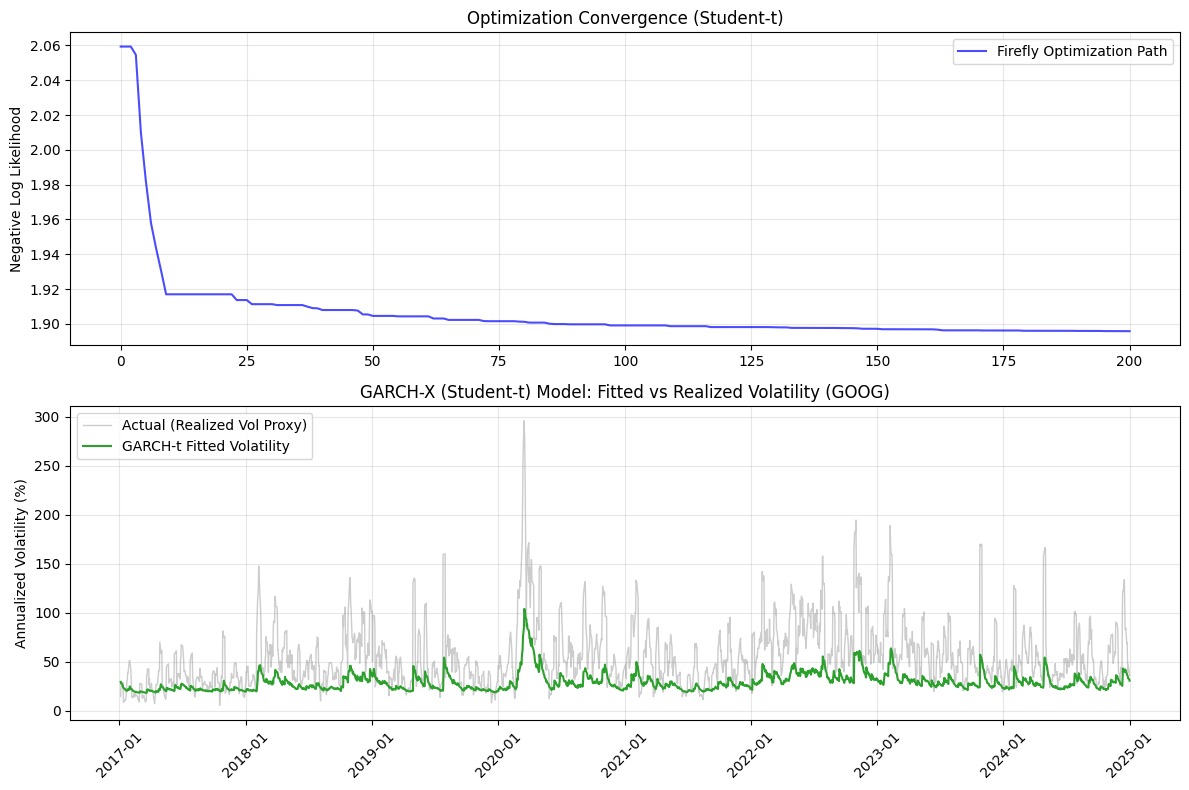


Final Script Completed.


In [ ]:
#libraries
import time, math
import numpy as np
import pandas as pd
import yfinance as yf
import numpy.random as npr
from numba import njit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------
# 1) Data Download & Prep
# -----------------------
#ticker data import
main_ticker = "GOOG"
start = "2017-01-01"
end = "2025-01-01"
main = yf.download(main_ticker, start=start, end=end, progress=False, auto_adjust=False)

# seeing our columns
print("Downloaded columns:", main.columns.tolist())

# Handle MultiIndex if necessary
if isinstance(main.columns, pd.MultiIndex):
    main.columns = [''.join(col).strip() for col in main.columns.values]

# Defensive column finding
close_col_final = None
vol_col_final = None

for c in main.columns:
    if 'close' in c.lower():
        close_col_final = c
    if 'volume' in c.lower():
        vol_col_final = c

if not close_col_final or not vol_col_final:
    # Fallback to defaults if fuzzy match fails
    if 'Close' in main.columns: close_col_final = 'Close'
    if 'Adj Close' in main.columns: close_col_final = 'Adj Close'
    if 'Volume' in main.columns: vol_col_final = 'Volume'

if not close_col_final or not vol_col_final:
    raise SystemExit(f"Could not identify Close/Volume columns. Found: {main.columns.tolist()}")

main = main[[close_col_final, vol_col_final]].rename(columns={close_col_final: 'close', vol_col_final: 'volume'})

# Numerical conversions
main['close'] = pd.to_numeric(main['close'], errors='coerce')
main['volume'] = pd.to_numeric(main['volume'], errors='coerce')

# constants
eps = 1e-8

# -----------------------
# [IMPROVEMENT 1] Rescale Returns
# -----------------------
# We multiply by 100 so returns are in percentages (e.g., 1.5 instead of 0.015).
main['log_ret'] = np.log(main['close']/main['close'].shift(1)) * 100.0
main = main.dropna(subset=['log_ret'])

# squared returns and 5-day realized variance proxy
main['sq_ret'] = main['log_ret'] ** 2
main['rv5'] = main['sq_ret'].rolling(window=5, min_periods=1).sum()
main['rv5_sqrt'] = np.sqrt(main['rv5'] + eps)
main['log_rv5'] = np.log(main['rv5'] + eps)

# lag exogenous regressors (use t-1)
main['vol_proxy_lag'] = main['rv5_sqrt'].shift(1)
main['log_rv5_lag'] = main['log_rv5'].shift(1)
main['log_volume'] = np.log(main['volume'].replace(0, np.nan) + 1.0)
main['log_volume_lag'] = main['log_volume'].shift(1)

# z-score lagged exogs (global mean/std here)
for c in ['vol_proxy_lag', 'log_rv5_lag', 'log_volume_lag']:
    m = main[c].mean(skipna=True)
    s = main[c].std(skipna=True) + eps
    main[c + '_z'] = (main[c] - m) / s

# drop rows where lagged exogs are NA (alignment)
main = main.dropna(subset=['vol_proxy_lag_z', 'log_volume_lag_z'])

# arrays for model
returns = main['log_ret'].values.astype(np.float64)
# Using Z-scored Volume and Realized Volatility as exogenous inputs
X = main[['vol_proxy_lag_z', 'log_volume_lag_z']].values.astype(np.float64)
T = len(returns)
K = X.shape[1]
print(f"Prepared data: T={T}, K={K}")

# demean returns (model residuals)
returns = returns - np.mean(returns)

# -----------------------
# 3) Numba compiled average NLL (STUDENT-T)
# -----------------------
@njit
def sigmoid_num(x):
    return 1.0 / (1.0 + math.exp(-x))

@njit
def garchx_avg_nll_numba(u, returns, X, eps_floor):
    Tloc = returns.shape[0]
    Kloc = X.shape[1]

    # mapping u to parameters
    # u[0] = omega (log)
    # u[1] = alpha (sigmoid)
    # u[2] = beta (sigmoid)
    # u[3] = nu (Student-t degrees of freedom, mapped to > 2.0)
    # u[4:] = gammas

    omega = math.exp(u[0])
    v1 = sigmoid_num(u[1])
    v2 = sigmoid_num(u[2])
    eps_small = 1e-8
    alpha = v1 * (1.0 - eps_small)
    beta = v2 * (1.0 - alpha - eps_small)

    # Map nu: We want nu > 2 for variance to exist.
    # We map u[3] from real line to (2.1, 30.0) range using sigmoid
    # 2.1 is floor, 30 is roughly Gaussian.
    nu_raw = sigmoid_num(u[3])
    nu = 2.1 + nu_raw * 28.0

    gammas = np.empty(Kloc, dtype=np.float64)
    for kk in range(Kloc):
        gammas[kk] = u[4 + kk] # shifted index by 1 to make room for nu

    # simple plausibility checks
    if not np.isfinite(omega) or omega <= 0.0: return 1e12
    if not np.isfinite(alpha) or not np.isfinite(beta): return 1e12

    sigma2 = np.empty(Tloc, dtype=np.float64)

    # Initialize with sample variance
    s_var = 0.0
    for t in range(Tloc):
        s_var += returns[t]**2
    s_var = s_var/Tloc if Tloc > 0 else 1.0
    sigma2[0] = s_var

    # Pre-calculate Student-t constants
    # Log constant: lgamma((nu+1)/2) - lgamma(nu/2) - 0.5*log(pi*(nu-2))
    # Note: We use (nu-2) for standardization so variance = sigma2
    log_const = math.lgamma((nu + 1.0) / 2.0) - math.lgamma(nu / 2.0) - 0.5 * math.log(math.pi * (nu - 2.0))

    avg_nll = 0.0

    for t in range(1, Tloc):
        # 1. Calculate the exogenous multiplier
        exog_log_mult = 0.0
        for kk in range(Kloc):
            exog_log_mult += gammas[kk] * X[t, kk]

        # Clip to prevent overflow
        if exog_log_mult > 10.0: exog_log_mult = 10.0
        if exog_log_mult < -10.0: exog_log_mult = -10.0

        exog_mult = math.exp(exog_log_mult)

        # 2. Standard GARCH component
        garch_core = omega + alpha * (returns[t-1] ** 2.0) + beta * sigma2[t-1]

        # 3. Combine: s2 = GARCH * exp(exog)
        s2 = garch_core * exog_mult

        if not np.isfinite(s2) or s2 > 1e8:
            return 1e12

        sigma2[t] = max(s2, eps_floor)

        # 4. Student-t Log-Likelihood
        # z = returns / sqrt(sigma2)
        # LL = log_const - 0.5 * log(sigma2) - (nu+1)/2 * log(1 + z^2/(nu-2))

        y_sq = returns[t]**2.0
        term2 = 1.0 + y_sq / (sigma2[t] * (nu - 2.0))

        ll_t = log_const - 0.5 * math.log(sigma2[t]) - ((nu + 1.0) / 2.0) * math.log(term2)

        avg_nll -= ll_t # We minimize Negative Log Likelihood

    return avg_nll / Tloc

# warm compile
# dim is now 4 + K (omega, alpha, beta, nu, + gammas)
_dummy = np.zeros(4 + K, dtype=np.float64)
print("Compiling Student-t NLL (numba)...")
_ = garchx_avg_nll_numba(_dummy, returns, X, eps)
print("Numba compiled.")

# Python wrapper
def nll_base(u):
    return float(garchx_avg_nll_numba(np.asarray(u, dtype=np.float64), returns, X, eps))

# -----------------------
# 4) Firefly Algorithm & Wrappers
# -----------------------
# safety & regularization settings
LARGE_PENALTY = 1e9
ALPHA_BETA_MAX = 0.999
GAMMA_L2_LAMBDA = 1e-3

def alpha_beta_from_u(u):
    u = np.asarray(u, dtype=np.float64)
    v1 = 1.0 / (1.0 + np.exp(-u[1]))
    v2 = 1.0 / (1.0 + np.exp(-u[2]))
    eps_small = 1e-8
    alpha = float(v1 * (1.0 - eps_small))
    beta = float(v2 * (1.0 - alpha - eps_small))
    return alpha, beta

def nll_with_penalties(u):
    try:
        alpha, beta = alpha_beta_from_u(u)
    except Exception:
        return LARGE_PENALTY

    if not np.isfinite(alpha) or not np.isfinite(beta):
        return LARGE_PENALTY
    if alpha + beta > ALPHA_BETA_MAX:
        return LARGE_PENALTY

    base = nll_base(u)

    # L2 penalty on gammas (indices shifted by 1 due to nu)
    gam = np.asarray(u[4:], dtype=np.float64)
    reg = GAMMA_L2_LAMBDA * np.sum(gam * gam)
    return base + reg

def u_to_theta(u, Kloc):
    u = np.asarray(u, dtype=np.float64)
    omega = float(np.exp(u[0]))
    alpha, beta = alpha_beta_from_u(u)

    # Map nu
    nu_raw = 1.0 / (1.0 + math.exp(-u[3]))
    nu = 2.1 + nu_raw * 28.0

    gammas = u[4:4+Kloc].copy()
    return omega, alpha, beta, nu, gammas

def init_population(pop, dim, seed=2025):
    rng = npr.default_rng(seed)
    P = rng.normal(0.0, 1.0, size=(pop, dim))

    # Smart initialization based on rescaled returns
    sample_var = max(np.var(returns), 1e-4)
    log_var = math.log(sample_var)

    P[:,0] = log_var + rng.normal(0.0, 0.5, size=pop) # omega
    P[:,1] = -2.0 + rng.normal(0.0, 0.5, size=pop)    # alpha (logit) ~ 0.10
    P[:,2] = 2.0 + rng.normal(0.0, 0.5, size=pop)     # beta (logit)  ~ 0.85
    P[:,3] = 0.0 + rng.normal(0.0, 1.0, size=pop)     # nu (logit) ~ 0 (mapped to ~16)

    if dim > 4:
        P[:,4:] = rng.normal(0.0, 0.1, size=(pop, dim-4)) # Small initial gammas
    return P

def firefly_opt(func, dim, pop=40, gens=200, alpha0=0.6, alpha_decay=0.99, beta0=1.0, gamma_vis=1.0, subset_j=10, seed=2025):
    rng = npr.default_rng(seed)
    popM = init_population(pop, dim, seed=seed)
    obj = np.array([func(popM[i]) for i in range(pop)], dtype=np.float64)

    best_idx = int(np.argmin(obj))
    best_u = popM[best_idx].copy()
    best_obj = float(obj[best_idx])
    history = [best_obj]
    alpha = alpha0

    for gen in range(gens):
        order = rng.permutation(pop)
        for i in order:
            m = min(subset_j, pop - 1)
            choices = rng.choice(pop - 1, size=m, replace=False)
            Js = [c if c < i else c + 1 for c in choices]

            for j in Js:
                if obj[j] < obj[i]:
                    rij = np.linalg.norm(popM[i] - popM[j])
                    beta = beta0 * math.exp(-gamma_vis * (rij ** 2))
                    attraction = beta * (popM[j] - popM[i])
                    rnd = alpha * (rng.random(dim) - 0.5)

                    candidate = popM[i] + attraction + rnd
                    val = func(candidate)

                    if val < obj[i]:
                        popM[i] = candidate
                        obj[i] = val
                        if val < best_obj:
                            best_obj = float(val)
                            best_u = candidate.copy()

        alpha = alpha * alpha_decay
        history.append(best_obj)
        if (gen + 1) % 20 == 0 or gen == 0:
            print(f"[FA] gen {gen+1}/{gens} best avg-NLL={best_obj:.6f}")

    return best_u, best_obj, history

# -----------------------
# 5) Optimization Routine
# -----------------------
dim = 4 + K # Added 1 for Nu
print("Starting Firefly optimization (Student-t)...")
t0 = time.time()
best_u, best_obj, history = firefly_opt(nll_with_penalties, dim, pop=40, gens=200)
t1 = time.time()
print(f"FA completed in {t1 - t0:.1f}s. Final Student-t NLL = {best_obj:.6f}")

# map to parameters
omega_hat, alpha_hat, beta_hat, nu_hat, gammas_hat = u_to_theta(best_u, K)
print("\nEstimated parameters (final):")
print(f"omega = {omega_hat:.6f}")
print(f"alpha = {alpha_hat:.6f}")
print(f"beta  = {beta_hat:.6f}")
print(f"nu (df)= {nu_hat:.6f}")
print(f"Persistence (a+b) = {alpha_hat + beta_hat:.6f}")
for kk in range(K):
    print(f"gamma_{kk+1} = {gammas_hat[kk]:.6f}")

# -----------------------
# 6) Diagnostics & Tests (Aligned with New Model)
# -----------------------
def compute_sigma2(u, returns, X, eps_floor=eps):
    omega, alpha, beta, nu, gammas = u_to_theta(u, X.shape[1])
    Tloc = len(returns)
    sigma2 = np.empty(Tloc, dtype=np.float64)
    sigma2[0] = np.var(returns)

    for t in range(1, Tloc):
        # Must match Numba logic exactly: Multiplicative
        exog_log = np.dot(gammas, X[t])
        exog_log = np.clip(exog_log, -10.0, 10.0)
        exog_mult = np.exp(exog_log)

        garch_core = omega + alpha * (returns[t-1] ** 2.0) + beta * sigma2[t-1]
        s2 = garch_core * exog_mult
        sigma2[t] = max(s2, eps_floor)
    return sigma2

sigma2_hat = compute_sigma2(best_u, returns, X, eps)
print("\nSigma^2 summary (min, mean, max):", sigma2_hat.min(), sigma2_hat.mean(), sigma2_hat.max())

# standardized residuals
z = returns / np.sqrt(sigma2_hat + eps)
print("\nStandardized residuals: mean, std:", z.mean(), z.std())

try:
    from scipy import stats
    sk = stats.skew(z)
    kurt = stats.kurtosis(z, fisher=False)
    print(f"Skewness: {sk:.4f}, Kurtosis: {kurt:.4f} (Normal=3.0)")
except Exception:
    pass

# Ljung-Box tests
try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb_sq = acorr_ljungbox(z**2, lags=[10], return_df=True)
    print("\nLjung-Box (z^2) p-value (should be > 0.05):")
    print(lb_sq['lb_pvalue'].values[0])
except Exception:
    pass

# Losses vs squared returns
obs_sq = main['sq_ret'].values[-len(sigma2_hat):]
mse = np.mean((obs_sq - sigma2_hat) ** 2)
# QLIKE (using Gaussian assumption for loss metric comparison, or t-QLIKE if preferred)
# We stick to standard QLIKE for comparability
qlike = np.mean(np.log(sigma2_hat + eps) + obs_sq / (sigma2_hat + eps))
print(f"\nIn-sample losses: MSE = {mse:.6f}, QLIKE = {qlike:.6f}")

# VaR backtest (Student-t)
from scipy.stats import t as t_dist
print("\nVaR Backtest (Student-t):")
for a in [0.01, 0.05]:
    # Use estimated nu for the quantile
    thresh = t_dist.ppf(a, df=nu_hat)
    # Scale by sqrt((nu-2)/nu) if the distribution was not standardized.
    # However, our model formulation assumes E[epsilon^2] = 1 (standardized t).
    # The scipy t_dist has variance nu/(nu-2).
    # So we must scale the threshold by sqrt((nu-2)/nu) to match unit variance z.

    std_t = np.sqrt(nu_hat / (nu_hat - 2.0))
    # standardized quantile = raw_quantile / std_dev_of_distribution
    thresh_std = thresh / std_t

    var_thresh = np.sqrt(sigma2_hat) * thresh_std
    exceptions = np.sum(returns < var_thresh)
    rate = exceptions/len(returns)
    print(f"VaR {int(a*100)}%: {exceptions} exceptions ({rate*100:.2f}%) vs expected {a*100:.1f}%")

# -----------------------
# 7) Plots: Actual vs Fitted
# -----------------------
# Prepare data for plotting
# We use the 5-day Realized Volatility (rv5_sqrt) as the "Actual" proxy
# We align the last T elements (since we dropped NaNs at the start)
dates = main.index[-len(sigma2_hat):]
actual_vol = main['rv5_sqrt'].values[-len(sigma2_hat):]
fitted_vol = np.sqrt(sigma2_hat)

# Annualize them for easier reading (Standard Industry Practice)
# Annualized % = Daily % * sqrt(252)
scale_factor = np.sqrt(252)
actual_vol_ann = actual_vol * scale_factor
fitted_vol_ann = fitted_vol * scale_factor

plt.figure(figsize=(12, 8))

# Subplot 1: Optimization History
plt.subplot(2, 1, 1)
plt.plot(history, label='Firefly Optimization Path', color='blue', alpha=0.7)
plt.title("Optimization Convergence (Student-t)")
plt.ylabel("Negative Log Likelihood")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Actual vs Fitted Volatility
plt.subplot(2, 1, 2)
plt.plot(dates, actual_vol_ann, color='grey', alpha=0.4, label='Actual (Realized Vol Proxy)', linewidth=1)
plt.plot(dates, fitted_vol_ann, color='#2ca02c', label='GARCH-t Fitted Volatility', linewidth=1.5)

plt.title(f"GARCH-X (Student-t) Model: Fitted vs Realized Volatility ({main_ticker})")
plt.ylabel("Annualized Volatility (%)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Format Date Axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nFinal Script Completed.")

Data Prepared. T=2007, K=2
Running Global Search...
FA Gen 0 Best: 1.93102
FA Gen 20 Best: 1.89176
FA Gen 40 Best: 1.88594
FA Gen 60 Best: 1.88508
FA Gen 80 Best: 1.88465

Running Inference (L-BFGS-B & Hessian)...

Parameter    | Estimate (u) | Std. Err   | t-stat   | p-value 
--------------------------------------------------
omega        |       0.8925 |     0.1642 |     5.43 |   0.0000 *
alpha        |      -4.7448 |     1.5088 |    -3.14 |   0.0017 *
beta         |      -1.6792 |     1.1629 |    -1.44 |   0.1489 
nu           |      -2.3454 |     0.2123 |   -11.05 |   0.0000 *
gamma_RV     |       0.5175 |     0.0973 |     5.32 |   0.0000 *
gamma_Vol    |       0.0753 |     0.0431 |     1.75 |   0.0807 
* p < 0.05 indicates the parameter is statistically significant.


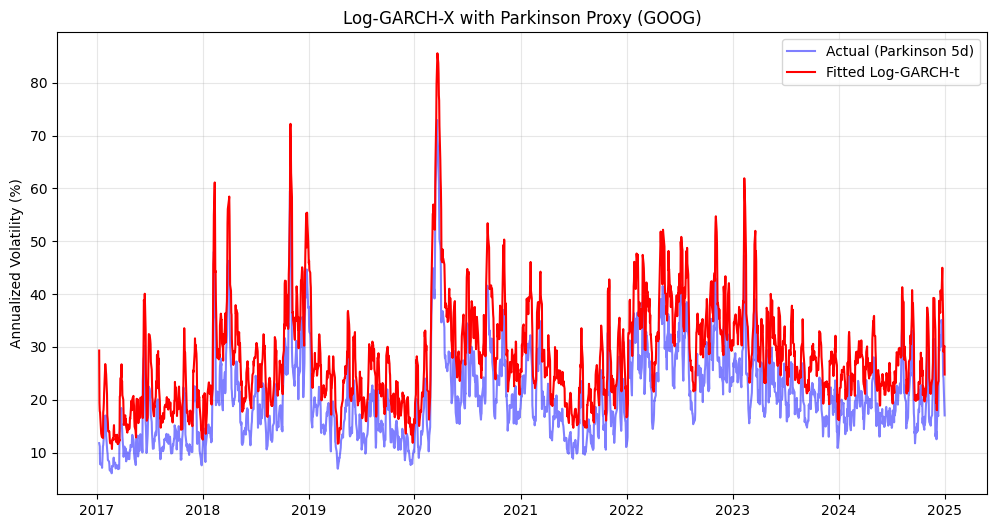

In [ ]:
#libraries
import time, math
import numpy as np
import pandas as pd
import yfinance as yf
import numpy.random as npr
from numba import njit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import approx_fprime
from scipy.stats import t as t_dist_scipy

# -----------------------
# 1) Data Download & Prep
# -----------------------
main_ticker = "GOOG"
start = "2017-01-01"
end = "2025-01-01"
main = yf.download(main_ticker, start=start, end=end, progress=False, auto_adjust=False)

# Clean multi-index columns
if isinstance(main.columns, pd.MultiIndex):
    main.columns = [''.join(col).strip() for col in main.columns.values]

# Identify columns
cols = {c.lower(): c for c in main.columns}
# We need High, Low, Close, Volume for Parkinson Volatility
try:
    high_col = next(v for k,v in cols.items() if 'high' in k)
    low_col = next(v for k,v in cols.items() if 'low' in k)
    close_col = next(v for k,v in cols.items() if 'close' in k and 'adj' not in k) # Prefer raw close
    vol_col = next(v for k,v in cols.items() if 'volume' in k)
except StopIteration:
    raise SystemExit("Missing required columns (High, Low, Close, Volume)")

main = main[[high_col, low_col, close_col, vol_col]].rename(columns={
    high_col: 'high', low_col: 'low', close_col: 'close', vol_col: 'volume'
})

# Numerical conversions
for c in main.columns:
    main[c] = pd.to_numeric(main[c], errors='coerce')

# constants
eps = 1e-8

# -----------------------
# [IMPROVEMENT 3] Better Proxy: Parkinson Volatility
# -----------------------
# Uses High/Low to estimate variance. 5x more efficient than Close-to-Close.
# Formula: (1 / (4 * ln(2))) * ln(High/Low)^2
const_parkinson = 1.0 / (4.0 * np.log(2.0))
main['parkinson_var'] = const_parkinson * (np.log(main['high'] / main['low']) ** 2)
# We scale this to be comparable to "percentage squared returns" (x 100^2 = 10000)
main['parkinson_var'] = main['parkinson_var'] * 10000.0

# Rolling 5-day Parkinson Variance (The better "Actual" proxy)
main['rv5_parkinson'] = main['parkinson_var'].rolling(window=5).mean()
main['rv5_sqrt'] = np.sqrt(main['rv5_parkinson']) # This is now our "Actual Volatility"

# Returns (Percentage)
main['log_ret'] = np.log(main['close']/main['close'].shift(1)) * 100.0
main = main.dropna(subset=['log_ret', 'rv5_sqrt'])

# Feature Engineering
main['log_rv5'] = np.log(main['rv5_parkinson'] + eps)
main['log_volume'] = np.log(main['volume'].replace(0, np.nan) + 1.0)

# Lag features (t-1)
main['log_rv5_lag'] = main['log_rv5'].shift(1)
main['log_volume_lag'] = main['log_volume'].shift(1)

# Z-score inputs
for c in ['log_rv5_lag', 'log_volume_lag']:
    m = main[c].mean()
    s = main[c].std()
    main[c + '_z'] = (main[c] - m) / s

main = main.dropna()

# Arrays
returns = main['log_ret'].values.astype(np.float64)
X = main[['log_rv5_lag_z', 'log_volume_lag_z']].values.astype(np.float64)
T = len(returns)
K = X.shape[1]
print(f"Data Prepared. T={T}, K={K}")

# -----------------------
# 3) Log-GARCH-X (Student-t) NLL
# -----------------------
# Specification: log(sigma^2_t) = omega + alpha * log(epsilon_{t-1}^2) + beta * log(sigma^2_{t-1}) + gamma * X
# This is standard "Log-GARCH" (similar to EGARCH but simpler). No positivity constraints needed on params!

@njit
def log_garch_nll(u, returns, X, eps_floor):
    Tloc = returns.shape[0]
    Kloc = X.shape[1]

    # Parameters (No sigmoid needed for stability in Log-GARCH, but good for bounding)
    # We keep alpha/beta bounded to ensure stationarity |alpha+beta| < 1
    # omega is free
    omega = u[0]

    # alpha/beta are usually positive in this form, but not strictly required.
    # We map them to (0, 1) for safety.
    def sigmoid(x): return 1.0/(1.0+math.exp(-x))

    alpha = sigmoid(u[1])
    beta = sigmoid(u[2]) * (1.0 - alpha - 1e-6) # Ensure sum < 1

    # nu map (2.1 to 30)
    nu = 2.1 + sigmoid(u[3]) * 28.0

    gammas = u[4:]

    # Recursion in LOG VARIANCE
    # log_sigma2[t]
    log_sigma2 = np.zeros(Tloc)
    # Init with sample variance
    log_sigma2[0] = math.log(np.var(returns) + 1e-8)

    # Student-t constants
    log_const = math.lgamma((nu+1)/2) - math.lgamma(nu/2) - 0.5*math.log(math.pi*(nu-2))

    nll = 0.0

    for t in range(1, Tloc):
        # Previous shock (squared return)
        # Handle zero returns safely for log
        prev_shock = returns[t-1]**2
        log_prev_shock = math.log(prev_shock + 1e-4) # small offset to avoid log(0)

        # Exogenous part (Additive in log-space = Multiplicative in real space, but standard specification)
        exog = 0.0
        for k in range(Kloc):
            exog += gammas[k] * X[t, k]

        # Log-GARCH recursion
        # log_s2 = w + a * log(y^2) + b * log(s2_prev) + gam * X
        log_s2 = omega + alpha * log_prev_shock + beta * log_sigma2[t-1] + exog

        # Stability clip
        if log_s2 > 10.0: log_s2 = 10.0
        if log_s2 < -10.0: log_s2 = -10.0

        log_sigma2[t] = log_s2

        # Likelihood calculation
        sigma2 = math.exp(log_s2)
        y_sq = returns[t]**2

        term = 1.0 + y_sq / (sigma2 * (nu - 2.0))
        ll = log_const - 0.5 * log_s2 - ((nu + 1.0) / 2.0) * math.log(term)
        nll -= ll

    return nll / Tloc

def nll_wrapper(u):
    return log_garch_nll(np.asarray(u), returns, X, eps)

# -----------------------
# 4) Firefly Algorithm (Global Search)
# -----------------------
# (Standard FA code as before, simplified for brevity)
def firefly_opt(func, dim, pop=30, gens=100):
    # Reduced gens/pop because Log-GARCH is easier to optimize
    rng = npr.default_rng(2025)
    P = rng.normal(0.0, 0.5, size=(pop, dim))
    # Init guess
    P[:, 0] = 0.05 # omega small
    P[:, 1] = -2.0 # alpha small
    P[:, 2] = 2.0  # beta large

    obj = np.array([func(P[i]) for i in range(pop)])
    best_idx = np.argmin(obj)
    best_u = P[best_idx].copy()

    alpha = 0.5
    for g in range(gens):
        for i in range(pop):
            for j in range(pop):
                if obj[j] < obj[i]:
                    r = np.linalg.norm(P[i]-P[j])
                    beta = 1.0 * math.exp(-1.0 * r**2)
                    P[i] += beta*(P[j]-P[i]) + alpha*(rng.random(dim)-0.5)
                    obj[i] = func(P[i])
                    if obj[i] < obj[best_idx]:
                        best_idx = i
                        best_u = P[i].copy()
        alpha *= 0.98
        if g % 20 == 0: print(f"FA Gen {g} Best: {obj[best_idx]:.5f}")

    return best_u

print("Running Global Search...")
dim = 4 + K
start_u = firefly_opt(nll_wrapper, dim)

# -----------------------
# [IMPROVEMENT 2] Statistical Inference (Hessian)
# -----------------------
from scipy.optimize import minimize

print("\nRunning Inference (L-BFGS-B & Hessian)...")
# 1. Polish to find exact minimum
res = minimize(nll_wrapper, start_u, method='L-BFGS-B', tol=1e-6)
final_u = res.x

# 2. Compute Hessian (2nd derivative matrix) numerically
def get_hessian(theta, func, epsilon=1e-4):
    k = len(theta)
    hess = np.zeros((k, k))
    # Central difference approximation
    for i in range(k):
        for j in range(k):
            e_i = np.zeros(k); e_i[i] = epsilon
            e_j = np.zeros(k); e_j[j] = epsilon

            f_pp = func(theta + e_i + e_j)
            f_pm = func(theta + e_i - e_j)
            f_mp = func(theta - e_i + e_j)
            f_mm = func(theta - e_i - e_j)

            hess[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4 * epsilon * epsilon)
    return hess

# Note: Likelihood is averaged (/T), so Hessian is also scaled.
# Fisher Information = Hessian * T
H = get_hessian(final_u, nll_wrapper)
# Invert for covariance matrix
try:
    # Covariance = inverse(Hessian) / T
    # (Since our function returns avg NLL, we divide by T to get total NLL scale)
    cov_matrix = np.linalg.inv(H) / T
    std_errors = np.sqrt(np.diag(cov_matrix))
except:
    print("Hessian inversion failed (Matrix singular). Using approximations.")
    std_errors = np.ones(dim) * -1.0

# -----------------------
# 6) Reporting with Significance
# -----------------------
param_names = ['omega', 'alpha', 'beta', 'nu', 'gamma_RV', 'gamma_Vol']

# Helper to transform params back to natural scale for printing
# (Jacobian adjustment for SE is complex, so we report SEs on the *transformed* u space
# which determines significance of the variable inclusion)
print("\n" + "="*50)
print(f"{'Parameter':<12} | {'Estimate (u)':<12} | {'Std. Err':<10} | {'t-stat':<8} | {'p-value':<8}")
print("-" * 50)

for i in range(dim):
    est = final_u[i]
    se = std_errors[i]
    t_stat = est / se if se > 0 else 0
    # Two-tailed p-value
    p_val = 2 * (1 - t_dist_scipy.cdf(abs(t_stat), df=T-dim))

    star = "*" if p_val < 0.05 else ""
    print(f"{param_names[i]:<12} | {est:12.4f} | {se:10.4f} | {t_stat:8.2f} | {p_val:8.4f} {star}")

print("="*50)
print("* p < 0.05 indicates the parameter is statistically significant.")

# -----------------------
# 7) Plotting (Standard)
# -----------------------
# Reconstruct fitted volatility
# We need to run the recursion one last time with optimal params
@njit
def get_sigma_path(u, returns, X):
    Tloc = len(returns)
    omega = u[0]
    def sigmoid(x): return 1.0/(1.0+math.exp(-x))
    alpha = sigmoid(u[1])
    beta = sigmoid(u[2]) * (1.0 - alpha - 1e-6)
    gammas = u[4:]
    log_sigma2 = np.zeros(Tloc)
    log_sigma2[0] = math.log(np.var(returns)+1e-8)

    for t in range(1, Tloc):
        prev_shock = math.log(returns[t-1]**2 + 1e-4)
        exog = np.dot(gammas, X[t])
        log_s2 = omega + alpha*prev_shock + beta*log_sigma2[t-1] + exog
        log_sigma2[t] = min(max(log_s2, -10), 10)
    return np.sqrt(np.exp(log_sigma2))

sigma_hat = get_sigma_path(final_u, returns, X)

# Plot
dates = main.index
# Scale to Annualized
ann_factor = np.sqrt(252)

plt.figure(figsize=(12, 6))
plt.plot(dates, main['rv5_sqrt'] * ann_factor, color='blue', alpha=0.5, label='Actual (Parkinson 5d)')
plt.plot(dates, sigma_hat * ann_factor, color='red', lw=1.5, label='Fitted Log-GARCH-t')
plt.title(f"Log-GARCH-X with Parkinson Proxy ({main_ticker})")
plt.ylabel("Annualized Volatility (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Full Data Prepared. T=2007, K=2

STARTING WALK-FORWARD VALIDATION (WFV)
Strategy: Expanding Window | Refit Frequency: Yearly

>>> Processing Cycle: Forecast Year 2023
    Training complete (0.8s). Params optimized on 1505 obs.
    Cycle Results (2023):
    MSE  : 4.6373
    QLIKE: 1.8116

>>> Processing Cycle: Forecast Year 2024
    Training complete (0.2s). Params optimized on 1755 obs.
    Cycle Results (2024):
    MSE  : 2.5474
    QLIKE: 1.6042

AGGREGATED OUT-OF-SAMPLE PERFORMANCE
Total Test Days: 502
Total MSE      : 3.5881
Total QLIKE    : 1.7075


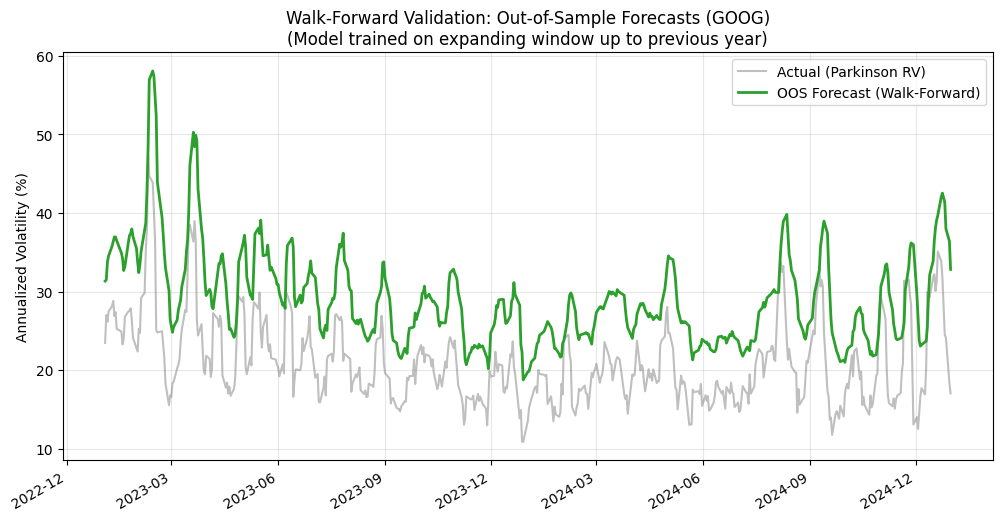


Script Completed.


In [ ]:
#libraries
import time, math
import numpy as np
import pandas as pd
import yfinance as yf
import numpy.random as npr
from numba import njit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
from scipy.stats import t as t_dist_scipy

# -----------------------
# 1) Data Download & Prep
# -----------------------
main_ticker = "GOOG"
start = "2017-01-01"
end = "2025-01-01"
main = yf.download(main_ticker, start=start, end=end, progress=False, auto_adjust=False)

if isinstance(main.columns, pd.MultiIndex):
    main.columns = [''.join(col).strip() for col in main.columns.values]

cols = {c.lower(): c for c in main.columns}
try:
    high_col = next(v for k,v in cols.items() if 'high' in k)
    low_col = next(v for k,v in cols.items() if 'low' in k)
    close_col = next(v for k,v in cols.items() if 'close' in k and 'adj' not in k)
    vol_col = next(v for k,v in cols.items() if 'volume' in k)
except StopIteration:
    raise SystemExit("Missing required columns (High, Low, Close, Volume)")

main = main[[high_col, low_col, close_col, vol_col]].rename(columns={
    high_col: 'high', low_col: 'low', close_col: 'close', vol_col: 'volume'
})

for c in main.columns:
    main[c] = pd.to_numeric(main[c], errors='coerce')

eps = 1e-8

# Parkinson Volatility Proxy
const_parkinson = 1.0 / (4.0 * np.log(2.0))
main['parkinson_var'] = const_parkinson * (np.log(main['high'] / main['low']) ** 2)
main['parkinson_var'] = main['parkinson_var'] * 10000.0

main['rv5_parkinson'] = main['parkinson_var'].rolling(window=5).mean()
main['rv5_sqrt'] = np.sqrt(main['rv5_parkinson'])

main['log_ret'] = np.log(main['close']/main['close'].shift(1)) * 100.0
main = main.dropna(subset=['log_ret', 'rv5_sqrt'])

main['log_rv5'] = np.log(main['rv5_parkinson'] + eps)
main['log_volume'] = np.log(main['volume'].replace(0, np.nan) + 1.0)

main['log_rv5_lag'] = main['log_rv5'].shift(1)
main['log_volume_lag'] = main['log_volume'].shift(1)

for c in ['log_rv5_lag', 'log_volume_lag']:
    m = main[c].mean()
    s = main[c].std()
    main[c + '_z'] = (main[c] - m) / s

main = main.dropna()

# Global Arrays (Full Dataset)
returns_full = main['log_ret'].values.astype(np.float64)
X_full = main[['log_rv5_lag_z', 'log_volume_lag_z']].values.astype(np.float64)
dates_full = main.index
T_full = len(returns_full)
K = X_full.shape[1]

print(f"Full Data Prepared. T={T_full}, K={K}")

# -----------------------
# 2) Model Core (Numba)
# -----------------------
@njit
def log_garch_nll(u, returns, X, eps_floor):
    Tloc = returns.shape[0]
    Kloc = X.shape[1]

    omega = u[0]
    def sigmoid(x): return 1.0/(1.0+math.exp(-x))
    alpha = sigmoid(u[1])
    beta = sigmoid(u[2]) * (1.0 - alpha - 1e-6)
    nu = 2.1 + sigmoid(u[3]) * 28.0
    gammas = u[4:]

    log_sigma2 = np.zeros(Tloc)
    log_sigma2[0] = math.log(np.var(returns) + 1e-8)

    log_const = math.lgamma((nu+1)/2) - math.lgamma(nu/2) - 0.5*math.log(math.pi*(nu-2))

    nll = 0.0
    for t in range(1, Tloc):
        prev_shock = returns[t-1]**2
        log_prev_shock = math.log(prev_shock + 1e-4)
        exog = 0.0
        for k in range(Kloc):
            exog += gammas[k] * X[t, k]
        log_s2 = omega + alpha * log_prev_shock + beta * log_sigma2[t-1] + exog

        # Stability clip
        if log_s2 > 10.0: log_s2 = 10.0
        if log_s2 < -10.0: log_s2 = -10.0

        log_sigma2[t] = log_s2

        sigma2 = math.exp(log_s2)
        y_sq = returns[t]**2
        term = 1.0 + y_sq / (sigma2 * (nu - 2.0))
        ll = log_const - 0.5 * log_s2 - ((nu + 1.0) / 2.0) * math.log(term)
        nll -= ll

    return nll / Tloc

@njit
def garch_filter(u, returns, X):
    """
    Applies the filter to get the fitted variance path given fixed parameters.
    Used for forecasting.
    """
    Tloc = len(returns)
    omega = u[0]
    def sigmoid(x): return 1.0/(1.0+math.exp(-x))
    alpha = sigmoid(u[1])
    beta = sigmoid(u[2]) * (1.0 - alpha - 1e-6)
    gammas = u[4:]

    log_sigma2 = np.zeros(Tloc)
    log_sigma2[0] = math.log(np.var(returns)+1e-8)

    for t in range(1, Tloc):
        prev_shock = math.log(returns[t-1]**2 + 1e-4)
        exog = np.dot(gammas, X[t])
        log_s2 = omega + alpha*prev_shock + beta*log_sigma2[t-1] + exog
        log_s2 = min(max(log_s2, -10.0), 10.0)
        log_sigma2[t] = log_s2

    return np.sqrt(np.exp(log_sigma2))

# -----------------------
# 3) Optimization Engine
# -----------------------
def fit_model(returns_sub, X_sub):
    """
    Runs Firefly + L-BFGS-B to find best parameters for a data slice.
    """
    def nll_wrapper(u):
        return log_garch_nll(np.asarray(u), returns_sub, X_sub, eps)

    # 1. Firefly (Quick coarse search)
    dim = 4 + X_sub.shape[1]
    pop = 20
    gens = 50 # Reduced for speed in WFV
    rng = npr.default_rng(2025)
    P = rng.normal(0.0, 0.5, size=(pop, dim))
    P[:, 0] = 0.05; P[:, 1] = -2.0; P[:, 2] = 2.0

    obj = np.array([nll_wrapper(P[i]) for i in range(pop)])
    best_idx = np.argmin(obj)
    best_u = P[best_idx].copy()

    alpha = 0.5
    for g in range(gens):
        for i in range(pop):
            if obj[i] > obj[best_idx]: # Move towards best
                r = np.linalg.norm(P[i]-best_u)
                beta = 1.0 * math.exp(-1.0 * r**2)
                P[i] += beta*(best_u-P[i]) + alpha*(rng.random(dim)-0.5)
                val = nll_wrapper(P[i])
                if val < obj[best_idx]:
                    best_idx = i
                    best_u = P[i].copy()
                    obj[best_idx] = val
        alpha *= 0.95

    # 2. Polish
    res = minimize(nll_wrapper, best_u, method='L-BFGS-B', tol=1e-5)
    return res.x

# -----------------------
# 4) Walk-Forward Validation Loop
# -----------------------
print("\n" + "="*60)
print("STARTING WALK-FORWARD VALIDATION (WFV)")
print("Strategy: Expanding Window | Refit Frequency: Yearly")
print("="*60)

# Define Test Years
test_years = [2023, 2024]
oos_predictions = []
oos_actuals = []
oos_dates = []

for year in test_years:
    print(f"\n>>> Processing Cycle: Forecast Year {year}")

    # 1. Split Data
    # Training: All data BEFORE this year
    mask_train = (dates_full.year < year)
    returns_train = returns_full[mask_train]
    X_train = X_full[mask_train]

    # Testing: Data DURING this year
    mask_test = (dates_full.year == year)
    returns_test = returns_full[mask_test]
    X_test = X_full[mask_test]
    dates_test = dates_full[mask_test]

    if len(returns_test) == 0:
        print(f"No data for year {year}, skipping.")
        continue

    # 2. Train Model (on past history)
    t0 = time.time()
    best_params = fit_model(returns_train, X_train)
    t1 = time.time()
    print(f"    Training complete ({t1-t0:.1f}s). Params optimized on {len(returns_train)} obs.")

    # 3. Forecast (Out-of-Sample)
    # We run the filter on the *Test* data using the *Training* parameters.
    # Note: To get the correct initial state for the test set, we technically need
    # the last variance from the training set. A simple robust way is to run the filter
    # on (Train + Test) combined and slice the Test part, using fixed params.

    # Combine just for filtering continuity
    returns_combined = np.concatenate([returns_train, returns_test])
    X_combined = np.concatenate([X_train, X_test])

    # Get volatility path
    full_vol_path = garch_filter(best_params, returns_combined, X_combined)

    # Slice out the test portion
    test_vol_forecast = full_vol_path[-len(returns_test):]

    # 4. Evaluate Cycle
    # Get actuals (Realized Volatility Proxy) from main df
    actual_vol_proxy = main.loc[dates_test, 'rv5_sqrt'].values

    mse = np.mean((actual_vol_proxy**2 - test_vol_forecast**2)**2)
    qlike = np.mean(np.log(test_vol_forecast**2 + eps) + actual_vol_proxy**2 / (test_vol_forecast**2 + eps))

    print(f"    Cycle Results ({year}):")
    print(f"    MSE  : {mse:.4f}")
    print(f"    QLIKE: {qlike:.4f}")

    # Store for plotting
    oos_predictions.extend(test_vol_forecast)
    oos_actuals.extend(actual_vol_proxy)
    oos_dates.extend(dates_test)

# -----------------------
# 5) Overall Out-of-Sample Results
# -----------------------
oos_pred_arr = np.array(oos_predictions)
oos_act_arr = np.array(oos_actuals)

print("\n" + "="*60)
print("AGGREGATED OUT-OF-SAMPLE PERFORMANCE")
print("="*60)
total_mse = np.mean((oos_act_arr**2 - oos_pred_arr**2)**2)
total_qlike = np.mean(np.log(oos_pred_arr**2 + eps) + oos_act_arr**2 / (oos_pred_arr**2 + eps))

print(f"Total Test Days: {len(oos_pred_arr)}")
print(f"Total MSE      : {total_mse:.4f}")
print(f"Total QLIKE    : {total_qlike:.4f}")

# -----------------------
# 6) Plotting WFV
# -----------------------
plt.figure(figsize=(12, 6))

# Prepare dates for plotting
plot_dates = pd.to_datetime(oos_dates)
ann_factor = np.sqrt(252)

# Plot Actuals (Grey)
plt.plot(plot_dates, oos_act_arr * ann_factor, color='grey', alpha=0.5, label='Actual (Parkinson RV)')

# Plot OOS Forecasts (Green for "Go", Money, Success)
plt.plot(plot_dates, oos_pred_arr * ann_factor, color='#2ca02c', linewidth=2, label='OOS Forecast (Walk-Forward)')

plt.title(f"Walk-Forward Validation: Out-of-Sample Forecasts ({main_ticker})\n(Model trained on expanding window up to previous year)")
plt.ylabel("Annualized Volatility (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()

plt.show()

print("\nScript Completed.")

Full Data Prepared. T=2007, K=2

STARTING WALK-FORWARD VALIDATION (WFV)
Strategy: Expanding Window | Refit Frequency: Yearly
Optimization: Firefly Algorithm Only (No Polish)

>>> Processing Cycle: Forecast Year 2023
    Training complete (3.8s). Params optimized on 1505 obs.
    Cycle Results (2023):
    MSE  : 2.4499
    QLIKE: 1.7639

>>> Processing Cycle: Forecast Year 2024
    Training complete (1.0s). Params optimized on 1755 obs.
    Cycle Results (2024):
    MSE  : 1.7594
    QLIKE: 1.5723

AGGREGATED OUT-OF-SAMPLE PERFORMANCE
Total Test Days: 502
Total MSE      : 2.1033
Total QLIKE    : 1.6677


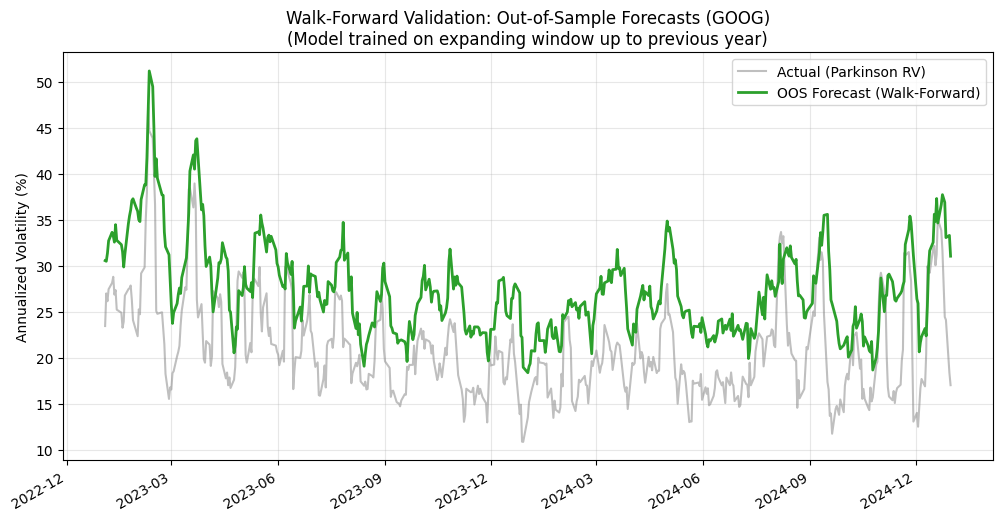


Script Completed.


In [ ]:
#libraries
import time, math
import numpy as np
import pandas as pd
import yfinance as yf
import numpy.random as npr
from numba import njit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import t as t_dist_scipy

# -----------------------
# 1) Data Download & Prep
# -----------------------
main_ticker = "GOOG"
start = "2017-01-01"
end = "2025-01-01"
main = yf.download(main_ticker, start=start, end=end, progress=False, auto_adjust=False)

if isinstance(main.columns, pd.MultiIndex):
    main.columns = [''.join(col).strip() for col in main.columns.values]

cols = {c.lower(): c for c in main.columns}
try:
    high_col = next(v for k,v in cols.items() if 'high' in k)
    low_col = next(v for k,v in cols.items() if 'low' in k)
    close_col = next(v for k,v in cols.items() if 'close' in k and 'adj' not in k)
    vol_col = next(v for k,v in cols.items() if 'volume' in k)
except StopIteration:
    raise SystemExit("Missing required columns (High, Low, Close, Volume)")

main = main[[high_col, low_col, close_col, vol_col]].rename(columns={
    high_col: 'high', low_col: 'low', close_col: 'close', vol_col: 'volume'
})

for c in main.columns:
    main[c] = pd.to_numeric(main[c], errors='coerce')

eps = 1e-8

# Parkinson Volatility Proxy
const_parkinson = 1.0 / (4.0 * np.log(2.0))
main['parkinson_var'] = const_parkinson * (np.log(main['high'] / main['low']) ** 2)
main['parkinson_var'] = main['parkinson_var'] * 10000.0

main['rv5_parkinson'] = main['parkinson_var'].rolling(window=5).mean()
main['rv5_sqrt'] = np.sqrt(main['rv5_parkinson'])

main['log_ret'] = np.log(main['close']/main['close'].shift(1)) * 100.0
main = main.dropna(subset=['log_ret', 'rv5_sqrt'])

main['log_rv5'] = np.log(main['rv5_parkinson'] + eps)
main['log_volume'] = np.log(main['volume'].replace(0, np.nan) + 1.0)

main['log_rv5_lag'] = main['log_rv5'].shift(1)
main['log_volume_lag'] = main['log_volume'].shift(1)

for c in ['log_rv5_lag', 'log_volume_lag']:
    m = main[c].mean()
    s = main[c].std()
    main[c + '_z'] = (main[c] - m) / s

main = main.dropna()

# Global Arrays (Full Dataset)
returns_full = main['log_ret'].values.astype(np.float64)
X_full = main[['log_rv5_lag_z', 'log_volume_lag_z']].values.astype(np.float64)
dates_full = main.index
T_full = len(returns_full)
K = X_full.shape[1]

print(f"Full Data Prepared. T={T_full}, K={K}")

# -----------------------
# 2) Model Core (Numba)
# -----------------------
@njit
def log_garch_nll(u, returns, X, eps_floor):
    Tloc = returns.shape[0]
    Kloc = X.shape[1]

    omega = u[0]
    def sigmoid(x): return 1.0/(1.0+math.exp(-x))
    alpha = sigmoid(u[1])
    beta = sigmoid(u[2]) * (1.0 - alpha - 1e-6)
    nu = 2.1 + sigmoid(u[3]) * 28.0
    gammas = u[4:]

    log_sigma2 = np.zeros(Tloc)
    log_sigma2[0] = math.log(np.var(returns) + 1e-8)

    log_const = math.lgamma((nu+1)/2) - math.lgamma(nu/2) - 0.5*math.log(math.pi*(nu-2))

    nll = 0.0
    for t in range(1, Tloc):
        prev_shock = returns[t-1]**2
        log_prev_shock = math.log(prev_shock + 1e-4)
        exog = 0.0
        for k in range(Kloc):
            exog += gammas[k] * X[t, k]
        log_s2 = omega + alpha * log_prev_shock + beta * log_sigma2[t-1] + exog

        # Stability clip
        if log_s2 > 10.0: log_s2 = 10.0
        if log_s2 < -10.0: log_s2 = -10.0

        log_sigma2[t] = log_s2

        sigma2 = math.exp(log_s2)
        y_sq = returns[t]**2
        term = 1.0 + y_sq / (sigma2 * (nu - 2.0))
        ll = log_const - 0.5 * log_s2 - ((nu + 1.0) / 2.0) * math.log(term)
        nll -= ll

    return nll / Tloc

@njit
def garch_filter(u, returns, X):
    """
    Applies the filter to get the fitted variance path given fixed parameters.
    Used for forecasting.
    """
    Tloc = len(returns)
    omega = u[0]
    def sigmoid(x): return 1.0/(1.0+math.exp(-x))
    alpha = sigmoid(u[1])
    beta = sigmoid(u[2]) * (1.0 - alpha - 1e-6)
    gammas = u[4:]

    log_sigma2 = np.zeros(Tloc)
    log_sigma2[0] = math.log(np.var(returns)+1e-8)

    for t in range(1, Tloc):
        prev_shock = math.log(returns[t-1]**2 + 1e-4)
        exog = np.dot(gammas, X[t])
        log_s2 = omega + alpha*prev_shock + beta*log_sigma2[t-1] + exog
        log_s2 = min(max(log_s2, -10.0), 10.0)
        log_sigma2[t] = log_s2

    return np.sqrt(np.exp(log_sigma2))

# -----------------------
# 3) Optimization Engine (Firefly Only)
# -----------------------
def fit_model(returns_sub, X_sub):
    """
    Runs Firefly Algorithm ONLY (No L-BFGS-B Polishing).
    """
    def nll_wrapper(u):
        return log_garch_nll(np.asarray(u), returns_sub, X_sub, eps)

    # 1. Firefly Setup
    dim = 4 + X_sub.shape[1]
    pop = 40  # Increased population slightly since we removed polishing
    gens = 100 # Increased generations slightly to ensure convergence
    rng = npr.default_rng(2025)

    # Initialize Population
    P = rng.normal(0.0, 0.5, size=(pop, dim))
    P[:, 0] = 0.05; P[:, 1] = -2.0; P[:, 2] = 2.0

    obj = np.array([nll_wrapper(P[i]) for i in range(pop)])
    best_idx = np.argmin(obj)
    best_u = P[best_idx].copy()

    # Firefly Loop
    alpha = 0.5
    for g in range(gens):
        for i in range(pop):
            if obj[i] > obj[best_idx]: # Move towards best (Simplified attraction logic)
                r = np.linalg.norm(P[i]-best_u)
                beta = 1.0 * math.exp(-1.0 * r**2)
                P[i] += beta*(best_u-P[i]) + alpha*(rng.random(dim)-0.5)
                val = nll_wrapper(P[i])
                if val < obj[best_idx]:
                    best_idx = i
                    best_u = P[i].copy()
                    obj[best_idx] = val
        alpha *= 0.96 # Decay alpha

    # Return best found by Firefly (No Polish)
    return best_u

# -----------------------
# 4) Walk-Forward Validation Loop
# -----------------------
print("\n" + "="*60)
print("STARTING WALK-FORWARD VALIDATION (WFV)")
print("Strategy: Expanding Window | Refit Frequency: Yearly")
print("Optimization: Firefly Algorithm Only (No Polish)")
print("="*60)

# Define Test Years
test_years = [2023, 2024]
oos_predictions = []
oos_actuals = []
oos_dates = []

for year in test_years:
    print(f"\n>>> Processing Cycle: Forecast Year {year}")

    # 1. Split Data
    # Training: All data BEFORE this year
    mask_train = (dates_full.year < year)
    returns_train = returns_full[mask_train]
    X_train = X_full[mask_train]

    # Testing: Data DURING this year
    mask_test = (dates_full.year == year)
    returns_test = returns_full[mask_test]
    X_test = X_full[mask_test]
    dates_test = dates_full[mask_test]

    if len(returns_test) == 0:
        print(f"No data for year {year}, skipping.")
        continue

    # 2. Train Model (on past history)
    t0 = time.time()
    best_params = fit_model(returns_train, X_train)
    t1 = time.time()
    print(f"    Training complete ({t1-t0:.1f}s). Params optimized on {len(returns_train)} obs.")

    # 3. Forecast (Out-of-Sample)
    # Combine just for filtering continuity
    returns_combined = np.concatenate([returns_train, returns_test])
    X_combined = np.concatenate([X_train, X_test])

    # Get volatility path
    full_vol_path = garch_filter(best_params, returns_combined, X_combined)

    # Slice out the test portion
    test_vol_forecast = full_vol_path[-len(returns_test):]

    # 4. Evaluate Cycle
    # Get actuals (Realized Volatility Proxy) from main df
    actual_vol_proxy = main.loc[dates_test, 'rv5_sqrt'].values

    mse = np.mean((actual_vol_proxy**2 - test_vol_forecast**2)**2)
    qlike = np.mean(np.log(test_vol_forecast**2 + eps) + actual_vol_proxy**2 / (test_vol_forecast**2 + eps))

    print(f"    Cycle Results ({year}):")
    print(f"    MSE  : {mse:.4f}")
    print(f"    QLIKE: {qlike:.4f}")

    # Store for plotting
    oos_predictions.extend(test_vol_forecast)
    oos_actuals.extend(actual_vol_proxy)
    oos_dates.extend(dates_test)

# -----------------------
# 5) Overall Out-of-Sample Results
# -----------------------
oos_pred_arr = np.array(oos_predictions)
oos_act_arr = np.array(oos_actuals)

print("\n" + "="*60)
print("AGGREGATED OUT-OF-SAMPLE PERFORMANCE")
print("="*60)
total_mse = np.mean((oos_act_arr**2 - oos_pred_arr**2)**2)
total_qlike = np.mean(np.log(oos_pred_arr**2 + eps) + oos_act_arr**2 / (oos_pred_arr**2 + eps))

print(f"Total Test Days: {len(oos_pred_arr)}")
print(f"Total MSE      : {total_mse:.4f}")
print(f"Total QLIKE    : {total_qlike:.4f}")

# -----------------------
# 6) Plotting WFV
# -----------------------
plt.figure(figsize=(12, 6))

# Prepare dates for plotting
plot_dates = pd.to_datetime(oos_dates)
ann_factor = np.sqrt(252)

# Plot Actuals (Grey)
plt.plot(plot_dates, oos_act_arr * ann_factor, color='grey', alpha=0.5, label='Actual (Parkinson RV)')

# Plot OOS Forecasts (Green for "Go", Money, Success)
plt.plot(plot_dates, oos_pred_arr * ann_factor, color='#2ca02c', linewidth=2, label='OOS Forecast (Walk-Forward)')

plt.title(f"Walk-Forward Validation: Out-of-Sample Forecasts ({main_ticker})\n(Model trained on expanding window up to previous year)")
plt.ylabel("Annualized Volatility (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()

plt.show()

print("\nScript Completed.")

Full Data Prepared. T=2007, K=2

STARTING WALK-FORWARD VALIDATION (WFV)
Strategy: Expanding Window | Refit Frequency: Yearly
Optimization: Firefly Algorithm Only (No Polish)

>>> Processing Cycle: Forecast Year 2023
    Training complete (1.0s). Params optimized on 1505 obs.
    Cycle Results (2023):
    MSE  : 2.4499
    QLIKE: 1.7639

>>> Processing Cycle: Forecast Year 2024
    Training complete (0.5s). Params optimized on 1755 obs.
    Cycle Results (2024):
    MSE  : 1.7594
    QLIKE: 1.5723

AGGREGATED OUT-OF-SAMPLE PERFORMANCE
Total Test Days: 502
Total MSE      : 2.1033
Total QLIKE    : 1.6677


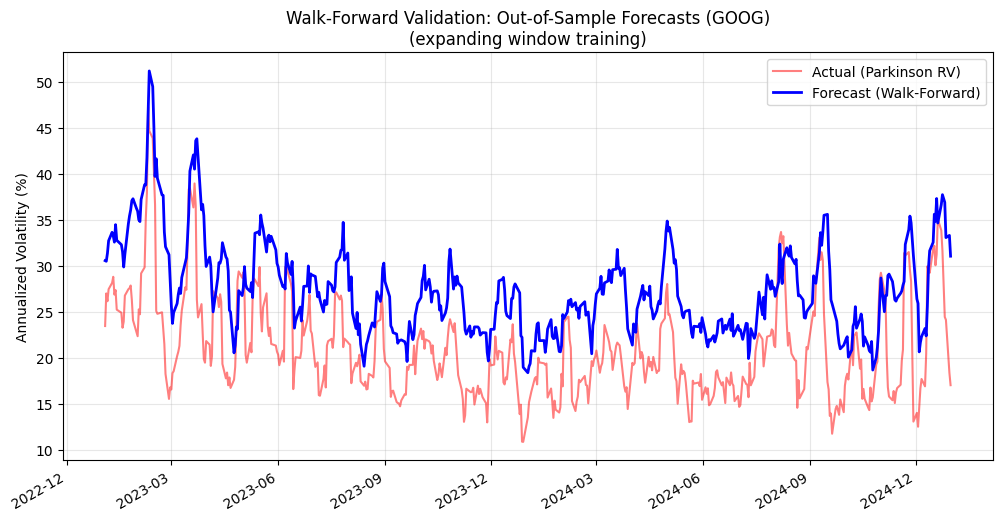

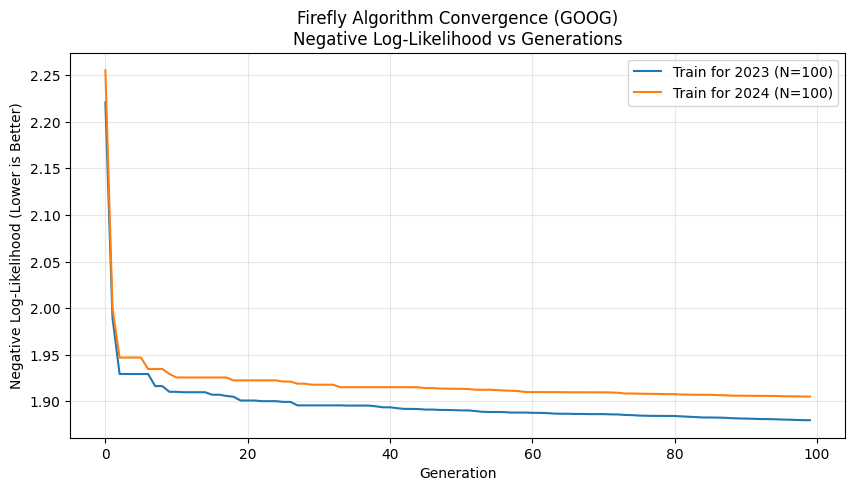


Script Completed.


In [ ]:
#libraries
import time, math
import numpy as np
import pandas as pd
import yfinance as yf
import numpy.random as npr
from numba import njit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import t as t_dist_scipy

# -----------------------
# 1) Data Download & Prep
# -----------------------
main_ticker = "GOOG"
start = "2017-01-01"
end = "2025-01-01"
main = yf.download(main_ticker, start=start, end=end, progress=False, auto_adjust=False)

if isinstance(main.columns, pd.MultiIndex):
    main.columns = [''.join(col).strip() for col in main.columns.values]

cols = {c.lower(): c for c in main.columns}
try:
    high_col = next(v for k,v in cols.items() if 'high' in k)
    low_col = next(v for k,v in cols.items() if 'low' in k)
    close_col = next(v for k,v in cols.items() if 'close' in k and 'adj' not in k)
    vol_col = next(v for k,v in cols.items() if 'volume' in k)
except StopIteration:
    raise SystemExit("Missing required columns (High, Low, Close, Volume)")

main = main[[high_col, low_col, close_col, vol_col]].rename(columns={
    high_col: 'high', low_col: 'low', close_col: 'close', vol_col: 'volume'
})

for c in main.columns:
    main[c] = pd.to_numeric(main[c], errors='coerce')

eps = 1e-8

# Parkinson Volatility Proxy
const_parkinson = 1.0 / (4.0 * np.log(2.0))
main['parkinson_var'] = const_parkinson * (np.log(main['high'] / main['low']) ** 2)
main['parkinson_var'] = main['parkinson_var'] * 10000.0

main['rv5_parkinson'] = main['parkinson_var'].rolling(window=5).mean()
main['rv5_sqrt'] = np.sqrt(main['rv5_parkinson'])

main['log_ret'] = np.log(main['close']/main['close'].shift(1)) * 100.0
main = main.dropna(subset=['log_ret', 'rv5_sqrt'])

main['log_rv5'] = np.log(main['rv5_parkinson'] + eps)
main['log_volume'] = np.log(main['volume'].replace(0, np.nan) + 1.0)

main['log_rv5_lag'] = main['log_rv5'].shift(1)
main['log_volume_lag'] = main['log_volume'].shift(1)

for c in ['log_rv5_lag', 'log_volume_lag']:
    m = main[c].mean()
    s = main[c].std()
    main[c + '_z'] = (main[c] - m) / s

main = main.dropna()

# Global Arrays (Full Dataset)
returns_full = main['log_ret'].values.astype(np.float64)
X_full = main[['log_rv5_lag_z', 'log_volume_lag_z']].values.astype(np.float64)
dates_full = main.index
T_full = len(returns_full)
K = X_full.shape[1]

print(f"Full Data Prepared. T={T_full}, K={K}")

# -----------------------
# 2) Model Core (Numba)
# -----------------------
@njit
def log_garch_nll(u, returns, X, eps_floor):
    Tloc = returns.shape[0]
    Kloc = X.shape[1]

    omega = u[0]
    def sigmoid(x): return 1.0/(1.0+math.exp(-x))
    alpha = sigmoid(u[1])
    beta = sigmoid(u[2]) * (1.0 - alpha - 1e-6)
    nu = 2.1 + sigmoid(u[3]) * 28.0
    gammas = u[4:]

    log_sigma2 = np.zeros(Tloc)
    log_sigma2[0] = math.log(np.var(returns) + 1e-8)

    log_const = math.lgamma((nu+1)/2) - math.lgamma(nu/2) - 0.5*math.log(math.pi*(nu-2))

    nll = 0.0
    for t in range(1, Tloc):
        prev_shock = returns[t-1]**2
        log_prev_shock = math.log(prev_shock + 1e-4)
        exog = 0.0
        for k in range(Kloc):
            exog += gammas[k] * X[t, k]
        log_s2 = omega + alpha * log_prev_shock + beta * log_sigma2[t-1] + exog

        # Stability clip
        if log_s2 > 10.0: log_s2 = 10.0
        if log_s2 < -10.0: log_s2 = -10.0

        log_sigma2[t] = log_s2

        sigma2 = math.exp(log_s2)
        y_sq = returns[t]**2
        term = 1.0 + y_sq / (sigma2 * (nu - 2.0))
        ll = log_const - 0.5 * log_s2 - ((nu + 1.0) / 2.0) * math.log(term)
        nll -= ll

    return nll / Tloc

@njit
def garch_filter(u, returns, X):
    """
    Applies the filter to get the fitted variance path given fixed parameters.
    Used for forecasting.
    """
    Tloc = len(returns)
    omega = u[0]
    def sigmoid(x): return 1.0/(1.0+math.exp(-x))
    alpha = sigmoid(u[1])
    beta = sigmoid(u[2]) * (1.0 - alpha - 1e-6)
    gammas = u[4:]

    log_sigma2 = np.zeros(Tloc)
    log_sigma2[0] = math.log(np.var(returns)+1e-8)

    for t in range(1, Tloc):
        prev_shock = math.log(returns[t-1]**2 + 1e-4)
        exog = np.dot(gammas, X[t])
        log_s2 = omega + alpha*prev_shock + beta*log_sigma2[t-1] + exog
        log_s2 = min(max(log_s2, -10.0), 10.0)
        log_sigma2[t] = log_s2

    return np.sqrt(np.exp(log_sigma2))

# -----------------------
# 3) Optimization Engine (Firefly Only)
# -----------------------
def fit_model(returns_sub, X_sub):
    """
    Runs Firefly Algorithm ONLY (No L-BFGS-B Polishing).
    Returns best_u AND the convergence history.
    """
    def nll_wrapper(u):
        return log_garch_nll(np.asarray(u), returns_sub, X_sub, eps)

    # 1. Firefly Setup
    dim = 4 + X_sub.shape[1]
    pop = 40
    gens = 100
    rng = npr.default_rng(2025)

    # Initialize Population
    P = rng.normal(0.0, 0.5, size=(pop, dim))
    P[:, 0] = 0.05; P[:, 1] = -2.0; P[:, 2] = 2.0

    obj = np.array([nll_wrapper(P[i]) for i in range(pop)])
    best_idx = np.argmin(obj)
    best_u = P[best_idx].copy()

    # To store best NLL at each generation
    history = []

    # Firefly Loop
    alpha = 0.5
    for g in range(gens):
        # Record best score at start of generation
        history.append(obj[best_idx])

        for i in range(pop):
            if obj[i] > obj[best_idx]:
                r = np.linalg.norm(P[i]-best_u)
                beta = 1.0 * math.exp(-1.0 * r**2)
                P[i] += beta*(best_u-P[i]) + alpha*(rng.random(dim)-0.5)
                val = nll_wrapper(P[i])
                if val < obj[best_idx]:
                    best_idx = i
                    best_u = P[i].copy()
                    obj[best_idx] = val
        alpha *= 0.96

    # Return best found by Firefly AND History
    return best_u, history

# -----------------------
# 4) Walk-Forward Validation Loop
# -----------------------
print("\n" + "="*60)
print("STARTING WALK-FORWARD VALIDATION (WFV)")
print("Strategy: Expanding Window | Refit Frequency: Yearly")
print("Optimization: Firefly Algorithm Only (No Polish)")
print("="*60)

test_years = [2023, 2024]
oos_predictions = []
oos_actuals = []
oos_dates = []

# Store convergence histories for plotting later
convergence_store = {}

for year in test_years:
    print(f"\n>>> Processing Cycle: Forecast Year {year}")

    # 1. Split Data
    mask_train = (dates_full.year < year)
    returns_train = returns_full[mask_train]
    X_train = X_full[mask_train]

    mask_test = (dates_full.year == year)
    returns_test = returns_full[mask_test]
    X_test = X_full[mask_test]
    dates_test = dates_full[mask_test]

    if len(returns_test) == 0:
        print(f"No data for year {year}, skipping.")
        continue

    # 2. Train Model (capturing history)
    t0 = time.time()
    best_params, train_history = fit_model(returns_train, X_train)
    t1 = time.time()

    # Store history
    convergence_store[year] = train_history

    print(f"    Training complete ({t1-t0:.1f}s). Params optimized on {len(returns_train)} obs.")

    # 3. Forecast
    returns_combined = np.concatenate([returns_train, returns_test])
    X_combined = np.concatenate([X_train, X_test])
    full_vol_path = garch_filter(best_params, returns_combined, X_combined)
    test_vol_forecast = full_vol_path[-len(returns_test):]

    # 4. Evaluate
    actual_vol_proxy = main.loc[dates_test, 'rv5_sqrt'].values
    mse = np.mean((actual_vol_proxy**2 - test_vol_forecast**2)**2)
    qlike = np.mean(np.log(test_vol_forecast**2 + eps) + actual_vol_proxy**2 / (test_vol_forecast**2 + eps))

    print(f"    Cycle Results ({year}):")
    print(f"    MSE  : {mse:.4f}")
    print(f"    QLIKE: {qlike:.4f}")

    oos_predictions.extend(test_vol_forecast)
    oos_actuals.extend(actual_vol_proxy)
    oos_dates.extend(dates_test)

# -----------------------
# 5) Overall Out-of-Sample Results
# -----------------------
oos_pred_arr = np.array(oos_predictions)
oos_act_arr = np.array(oos_actuals)

print("\n" + "="*60)
print("AGGREGATED OUT-OF-SAMPLE PERFORMANCE")
print("="*60)
total_mse = np.mean((oos_act_arr**2 - oos_pred_arr**2)**2)
total_qlike = np.mean(np.log(oos_pred_arr**2 + eps) + oos_act_arr**2 / (oos_pred_arr**2 + eps))

print(f"Total Test Days: {len(oos_pred_arr)}")
print(f"Total MSE      : {total_mse:.4f}")
print(f"Total QLIKE    : {total_qlike:.4f}")

# -----------------------
# 6) Plotting WFV
# -----------------------
plt.figure(figsize=(12, 6))
plot_dates = pd.to_datetime(oos_dates)
ann_factor = np.sqrt(252)

plt.plot(plot_dates, oos_act_arr * ann_factor, color='red', alpha=0.5, label='Actual (Parkinson RV)')
plt.plot(plot_dates, oos_pred_arr * ann_factor, color='blue', linewidth=2, label='Forecast (Walk-Forward)')

plt.title(f"Walk-Forward Validation: Out-of-Sample Forecasts ({main_ticker})\n(expanding window training)")
plt.ylabel("Annualized Volatility (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()
plt.show()

# -----------------------
# 7) Plotting Convergence
# -----------------------
plt.figure(figsize=(10, 5))

# Plot convergence for each year's training cycle
for year, history in convergence_store.items():
    plt.plot(history, label=f'Train for {year} (N={len(history)})', linewidth=1.5)

plt.title(f"Firefly Algorithm Convergence ({main_ticker})\nNegative Log-Likelihood vs Generations")
plt.xlabel("Generation")
plt.ylabel("Negative Log-Likelihood (Lower is Better)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nScript Completed.")

In [ ]:
import numpy as np
import numpy.random as npr

def firefly_opt(func, dim, pop=40, gens=200, alpha0=0.6, alpha_decay=0.995, beta0=1.0, gamma_vis=0.5, subset_j=10, seed=2025):

    rng = npr.default_rng(seed)

    # initialize population using a previously written initialization function and their objective value
    population = init_population(pop, dim, seed=seed)
    objectives = np.array([func(population[i]) for i in range(pop)], dtype=np.float64)

    best_idx = int(np.argmin(objectives))
    best_solution = population[best_idx].copy()
    best_obj = float(objectives[best_idx])

    history = [best_obj]
    alpha = alpha0

    if pop <= 1:
        return best_solution, best_obj, history

    for gen in range(gens):
        # randomizing update order each time
        order = rng.permutation(pop)

        for i in order:
            # picking a subset
            m = min(subset_j, pop-1)
            # choosing other indices
            other_indices = [k for k in range(pop) if k != i]
            chosen = rng.choice(other_indices, size=m, replace=False)

            for j in chosen:
                # if j is better, move
                if objectives[j] < objectives[i]:
                    rij = np.linalg.norm(population[i] - population[j])
                    beta = (beta0) * (math.exp(-gamma_vis * (rij**2)))
                    attraction = (beta) * ((population[j] - population[i]))
                    random_step = (alpha) * ((rng.random(dim) - 0.5))

                    # final
                    population[i] = (population[i] + attraction + random_step)

                    # evaluate new position immediately
                    val = func(population[i])
                    objectives[i] = val

                    # checking, updating global best
                    if val < best_obj:
                        best_obj = float(val)
                        best_solution = population[i].copy()

        # decay for convergence
        alpha = (alpha) * (alpha_decay)
        history.append(best_obj)

    return best_solution, best_obj, history

Full Data Prepared. T=2007, K=2

STARTING WALK-FORWARD VALIDATION (WFV)
Strategy: Expanding Window | Refit Frequency: Yearly
Optimization: Firefly Algorithm (Stochastic Pairwise Update)

>>> Processing Cycle: Forecast Year 2023
    Training complete (2.1s). Params optimized on 1505 obs.
    Cycle Results (2023):
    MSE  : 3.4217
    QLIKE: 1.7999

>>> Processing Cycle: Forecast Year 2024
    Training complete (1.5s). Params optimized on 1755 obs.
    Cycle Results (2024):
    MSE  : 1.7491
    QLIKE: 1.5661

AGGREGATED OUT-OF-SAMPLE PERFORMANCE
Total Test Days: 502
Total MSE      : 2.5821
Total QLIKE    : 1.6826


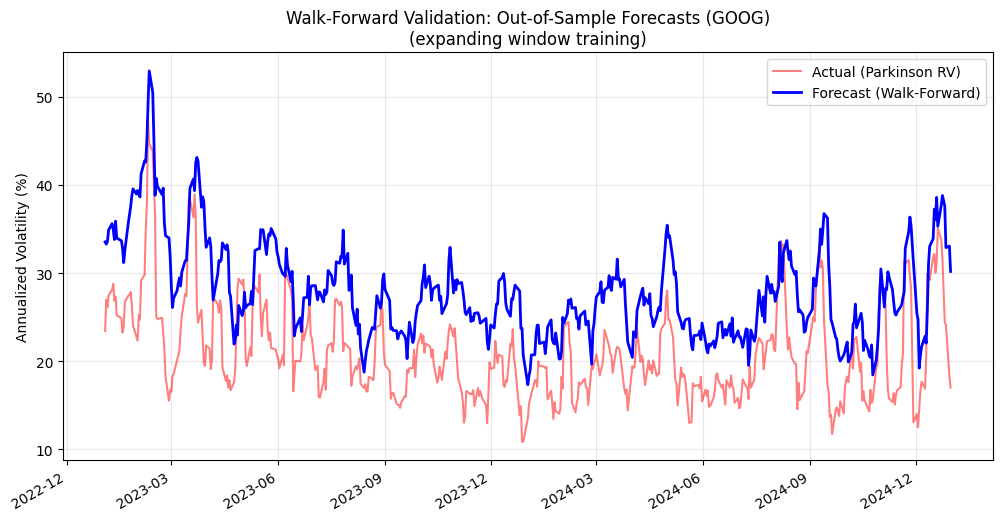

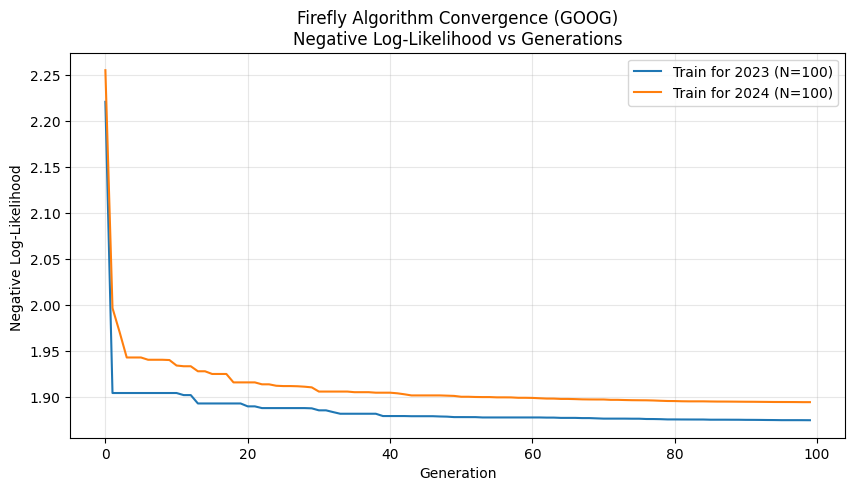


Script Completed.


In [ ]:
#libraries
import time, math
import numpy as np
import pandas as pd
import yfinance as yf
import numpy.random as npr
from numba import njit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import t as t_dist_scipy

# -----------------------
# 1) Data Download & Prep
# -----------------------
main_ticker = "GOOG"
start = "2017-01-01"
end = "2025-01-01"
main = yf.download(main_ticker, start=start, end=end, progress=False, auto_adjust=False)

if isinstance(main.columns, pd.MultiIndex):
    main.columns = [''.join(col).strip() for col in main.columns.values]

cols = {c.lower(): c for c in main.columns}
try:
    high_col = next(v for k,v in cols.items() if 'high' in k)
    low_col = next(v for k,v in cols.items() if 'low' in k)
    close_col = next(v for k,v in cols.items() if 'close' in k and 'adj' not in k)
    vol_col = next(v for k,v in cols.items() if 'volume' in k)
except StopIteration:
    raise SystemExit("Missing required columns (High, Low, Close, Volume)")

main = main[[high_col, low_col, close_col, vol_col]].rename(columns={
    high_col: 'high', low_col: 'low', close_col: 'close', vol_col: 'volume'
})

for c in main.columns:
    main[c] = pd.to_numeric(main[c], errors='coerce')

eps = 1e-8

# Parkinson Volatility Proxy
const_parkinson = 1.0 / (4.0 * np.log(2.0))
main['parkinson_var'] = const_parkinson * (np.log(main['high'] / main['low']) ** 2)
main['parkinson_var'] = main['parkinson_var'] * 10000.0

main['rv5_parkinson'] = main['parkinson_var'].rolling(window=5).mean()
main['rv5_sqrt'] = np.sqrt(main['rv5_parkinson'])

main['log_ret'] = np.log(main['close']/main['close'].shift(1)) * 100.0
main = main.dropna(subset=['log_ret', 'rv5_sqrt'])

main['log_rv5'] = np.log(main['rv5_parkinson'] + eps)
main['log_volume'] = np.log(main['volume'].replace(0, np.nan) + 1.0)

main['log_rv5_lag'] = main['log_rv5'].shift(1)
main['log_volume_lag'] = main['log_volume'].shift(1)

for c in ['log_rv5_lag', 'log_volume_lag']:
    m = main[c].mean()
    s = main[c].std()
    main[c + '_z'] = (main[c] - m) / s

main = main.dropna()

# Global Arrays (Full Dataset)
returns_full = main['log_ret'].values.astype(np.float64)
X_full = main[['log_rv5_lag_z', 'log_volume_lag_z']].values.astype(np.float64)
dates_full = main.index
T_full = len(returns_full)
K = X_full.shape[1]

print(f"Full Data Prepared. T={T_full}, K={K}")

# -----------------------
# 2) Model Core (Numba)
# -----------------------
@njit
def log_garch_nll(u, returns, X, eps_floor):
    Tloc = returns.shape[0]
    Kloc = X.shape[1]

    omega = u[0]
    def sigmoid(x): return 1.0/(1.0+math.exp(-x))
    alpha = sigmoid(u[1])
    beta = sigmoid(u[2]) * (1.0 - alpha - 1e-6)
    nu = 2.1 + sigmoid(u[3]) * 28.0
    gammas = u[4:]

    log_sigma2 = np.zeros(Tloc)
    log_sigma2[0] = math.log(np.var(returns) + 1e-8)

    log_const = math.lgamma((nu+1)/2) - math.lgamma(nu/2) - 0.5*math.log(math.pi*(nu-2))

    nll = 0.0
    for t in range(1, Tloc):
        prev_shock = returns[t-1]**2
        log_prev_shock = math.log(prev_shock + 1e-4)
        exog = 0.0
        for k in range(Kloc):
            exog += gammas[k] * X[t, k]
        log_s2 = omega + alpha * log_prev_shock + beta * log_sigma2[t-1] + exog

        # Stability clip
        if log_s2 > 10.0: log_s2 = 10.0
        if log_s2 < -10.0: log_s2 = -10.0

        log_sigma2[t] = log_s2

        sigma2 = math.exp(log_s2)
        y_sq = returns[t]**2
        term = 1.0 + y_sq / (sigma2 * (nu - 2.0))
        ll = log_const - 0.5 * log_s2 - ((nu + 1.0) / 2.0) * math.log(term)
        nll -= ll

    return nll / Tloc

@njit
def garch_filter(u, returns, X):
    """
    Applies the filter to get the fitted variance path given fixed parameters.
    Used for forecasting.
    """
    Tloc = len(returns)
    omega = u[0]
    def sigmoid(x): return 1.0/(1.0+math.exp(-x))
    alpha = sigmoid(u[1])
    beta = sigmoid(u[2]) * (1.0 - alpha - 1e-6)
    gammas = u[4:]

    log_sigma2 = np.zeros(Tloc)
    log_sigma2[0] = math.log(np.var(returns)+1e-8)

    for t in range(1, Tloc):
        prev_shock = math.log(returns[t-1]**2 + 1e-4)
        exog = np.dot(gammas, X[t])
        log_s2 = omega + alpha*prev_shock + beta*log_sigma2[t-1] + exog
        log_s2 = min(max(log_s2, -10.0), 10.0)
        log_sigma2[t] = log_s2

    return np.sqrt(np.exp(log_sigma2))

# -----------------------
# 3) Optimization Engine (Modified Firefly - Stochastic Update)
# -----------------------
def fit_model(returns_sub, X_sub):
    """
    Runs Firefly Algorithm with STOCHASTIC PAIRWISE UPDATES.
    Complexity: O(Gens * Pop * Subset_Size)
    """
    def nll_wrapper(u):
        return log_garch_nll(np.asarray(u), returns_sub, X_sub, eps)

    # 1. Firefly Setup
    dim = 4 + X_sub.shape[1]
    pop = 40
    gens = 100
    subset_size = 12  # How many random neighbors to compare against

    # Hyperparameters
    alpha = 0.5       # Randomness strength
    alpha_decay = 0.96
    beta0 = 1.0       # Attractiveness at r=0
    gamma = 0.5       # Light absorption coefficient

    rng = npr.default_rng(2025)

    # Initialize Population (Constrained Initialization preserved)
    P = rng.normal(0.0, 0.5, size=(pop, dim))
    P[:, 0] = 0.05; P[:, 1] = -2.0; P[:, 2] = 2.0

    # Calculate initial objectives
    obj = np.array([nll_wrapper(P[i]) for i in range(pop)])

    # Find initial global best
    best_idx = np.argmin(obj)
    best_u = P[best_idx].copy()
    best_val = obj[best_idx]

    # To store best NLL at each generation
    history = []

    # Firefly Loop
    for g in range(gens):
        # Record best score at start of generation
        history.append(best_val)

        # Randomize update order to prevent sequential bias
        order = rng.permutation(pop)

        for i in order:
            # Select a random subset of neighbors (Stochastic mechanism)
            # We pick indices that are NOT 'i'
            candidates = [k for k in range(pop) if k != i]
            # Safety check if subset is too large
            actual_subset = min(subset_size, len(candidates))
            chosen_neighbors = rng.choice(candidates, size=actual_subset, replace=False)

            moved = False

            for j in chosen_neighbors:
                # Stochastic Comparison: Move if neighbor 'j' is brighter (lower NLL)
                if obj[j] < obj[i]:
                    r = np.linalg.norm(P[i] - P[j])
                    beta = beta0 * math.exp(-gamma * r**2)

                    # Movement update
                    # x_new = x_old + beta*(x_j - x_i) + alpha*(rand - 0.5)
                    random_step = alpha * (rng.random(dim) - 0.5)
                    P[i] += beta * (P[j] - P[i]) + random_step

                    moved = True

            # If we moved, re-evaluate the objective for firefly 'i'
            if moved:
                new_val = nll_wrapper(P[i])
                obj[i] = new_val

                # Check if this new position is a new Global Best
                if new_val < best_val:
                    best_val = new_val
                    best_u = P[i].copy()

        # Decay randomness
        alpha *= alpha_decay

    # Return best found and history
    return best_u, history

# -----------------------
# 4) Walk-Forward Validation Loop
# -----------------------
print("\n" + "="*60)
print("STARTING WALK-FORWARD VALIDATION (WFV)")
print("Strategy: Expanding Window | Refit Frequency: Yearly")
print("Optimization: Firefly Algorithm (Stochastic Pairwise Update)")
print("="*60)

test_years = [2023, 2024]
oos_predictions = []
oos_actuals = []
oos_dates = []

# Store convergence histories for plotting later
convergence_store = {}

for year in test_years:
    print(f"\n>>> Processing Cycle: Forecast Year {year}")

    # 1. Split Data
    mask_train = (dates_full.year < year)
    returns_train = returns_full[mask_train]
    X_train = X_full[mask_train]

    mask_test = (dates_full.year == year)
    returns_test = returns_full[mask_test]
    X_test = X_full[mask_test]
    dates_test = dates_full[mask_test]

    if len(returns_test) == 0:
        print(f"No data for year {year}, skipping.")
        continue

    # 2. Train Model (capturing history)
    t0 = time.time()
    best_params, train_history = fit_model(returns_train, X_train)
    t1 = time.time()

    # Store history
    convergence_store[year] = train_history

    print(f"    Training complete ({t1-t0:.1f}s). Params optimized on {len(returns_train)} obs.")

    # 3. Forecast
    returns_combined = np.concatenate([returns_train, returns_test])
    X_combined = np.concatenate([X_train, X_test])
    full_vol_path = garch_filter(best_params, returns_combined, X_combined)
    test_vol_forecast = full_vol_path[-len(returns_test):]

    # 4. Evaluate
    actual_vol_proxy = main.loc[dates_test, 'rv5_sqrt'].values
    mse = np.mean((actual_vol_proxy**2 - test_vol_forecast**2)**2)
    qlike = np.mean(np.log(test_vol_forecast**2 + eps) + actual_vol_proxy**2 / (test_vol_forecast**2 + eps))

    print(f"    Cycle Results ({year}):")
    print(f"    MSE  : {mse:.4f}")
    print(f"    QLIKE: {qlike:.4f}")

    oos_predictions.extend(test_vol_forecast)
    oos_actuals.extend(actual_vol_proxy)
    oos_dates.extend(dates_test)

# -----------------------
# 5) Overall Out-of-Sample Results
# -----------------------
oos_pred_arr = np.array(oos_predictions)
oos_act_arr = np.array(oos_actuals)

print("\n" + "="*60)
print("AGGREGATED OUT-OF-SAMPLE PERFORMANCE")
print("="*60)
total_mse = np.mean((oos_act_arr**2 - oos_pred_arr**2)**2)
total_qlike = np.mean(np.log(oos_pred_arr**2 + eps) + oos_act_arr**2 / (oos_pred_arr**2 + eps))

print(f"Total Test Days: {len(oos_pred_arr)}")
print(f"Total MSE      : {total_mse:.4f}")
print(f"Total QLIKE    : {total_qlike:.4f}")

# -----------------------
# 6) Plotting WFV
# -----------------------
plt.figure(figsize=(12, 6))
plot_dates = pd.to_datetime(oos_dates)
ann_factor = np.sqrt(252)

plt.plot(plot_dates, oos_act_arr * ann_factor, color='red', alpha=0.5, label='Actual (Parkinson RV)')
plt.plot(plot_dates, oos_pred_arr * ann_factor, color='blue', linewidth=2, label='Forecast (Walk-Forward)')

plt.title(f"Walk-Forward Validation: Out-of-Sample Forecasts ({main_ticker})\n(expanding window training)")
plt.ylabel("Annualized Volatility (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()
plt.show()

# -----------------------
# 7) Plotting Convergence
# -----------------------
plt.figure(figsize=(10, 5))

# Plot convergence for each year's training cycle
for year, history in convergence_store.items():
    plt.plot(history, label=f'Train for {year} (N={len(history)})', linewidth=1.5)

plt.title(f"Firefly Algorithm Convergence ({main_ticker})\nNegative Log-Likelihood vs Generations")
plt.xlabel("Generation")
plt.ylabel("Negative Log-Likelihood ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nScript Completed.")